# Probability of Default (PD) Scorecard Development using WOE and Logistic Regression

## Objective

Develop a traditional Probability of Default (PD) scorecard to estimate customer credit risk using borrower characteristics and repayment behaviour.

The project follows an end-to-end scorecard modelling framework comprising data preprocessing, fine and coarse classing, WOE transformation, IV analysis, feature selection, logistic regression modelling, score scaling, model validation, and scorecard generation. The final scorecard delivers an interpretable, business-friendly, and production-ready solution for customer risk ranking and credit risk assessment.

### Dataset Information
This dataset contains information on default payments, demographic factors, credit data, history of payment, and bill statements of credit card clients in Taiwan from April 2005 to September 2005.

###### Content
There are 25 variables:

- ID: ID of each client
- LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit
- SEX: Gender (1=male, 2=female)
- EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
- MARRIAGE: Marital status (1=married, 2=single, 3=others)
- AGE: Age in years
- PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
- PAY_2: Repayment status in August, 2005 (scale same as above)
- PAY_3: Repayment status in July, 2005 (scale same as above)
- PAY_4: Repayment status in June, 2005 (scale same as above)
- PAY_5: Repayment status in May, 2005 (scale same as above)
- PAY_6: Repayment status in April, 2005 (scale same as above)
- BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)
- BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)
- BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)
- BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)
- BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)
- BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)
- PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)
- PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)
- PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)
- PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)
- PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)
- PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)
- default.payment.next.month: Default payment (1=yes, 0=no)

### Importing the inital neccessary libraries

In [1]:
# Standard Libraries
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

### Loading the dataset

In [2]:
df = pd.read_csv("UCI_Credit_Card.csv", low_memory=False)

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.00,2,2,1,24,2,2,-1,-1,-2,-2,3913.00,3102.00,689.00,0.00,0.00,0.00,0.00,689.00,0.00,0.00,0.00,0.00,1
1,2,120000.00,2,2,2,26,-1,2,0,0,0,2,2682.00,1725.00,2682.00,3272.00,3455.00,3261.00,0.00,1000.00,1000.00,1000.00,0.00,2000.00,1
2,3,90000.00,2,2,2,34,0,0,0,0,0,0,29239.00,14027.00,13559.00,14331.00,14948.00,15549.00,1518.00,1500.00,1000.00,1000.00,1000.00,5000.00,0
3,4,50000.00,2,2,1,37,0,0,0,0,0,0,46990.00,48233.00,49291.00,28314.00,28959.00,29547.00,2000.00,2019.00,1200.00,1100.00,1069.00,1000.00,0
4,5,50000.00,1,2,1,57,-1,0,-1,0,0,0,8617.00,5670.00,35835.00,20940.00,19146.00,19131.00,2000.00,36681.00,10000.00,9000.00,689.00,679.00,0


### Basic Data Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [5]:
df.describe(include='all').transpose()

,count,mean,std,min,25%,50%,75%,max
ID,30000.00,15000.50,8660.40,1.00,7500.75,15000.50,22500.25,30000.00
LIMIT_BAL,30000.00,167484.32,129747.66,10000.00,50000.00,140000.00,240000.00,1000000.00
SEX,30000.00,1.60,0.49,1.00,1.00,2.00,2.00,2.00
EDUCATION,30000.00,1.85,0.79,0.00,1.00,2.00,2.00,6.00
MARRIAGE,30000.00,1.55,0.52,0.00,1.00,2.00,2.00,3.00
AGE,30000.00,35.49,9.22,21.00,28.00,34.00,41.00,79.00
PAY_0,30000.00,-0.02,1.12,-2.00,-1.00,0.00,0.00,8.00
PAY_2,30000.00,-0.13,1.20,-2.00,-1.00,0.00,0.00,8.00
PAY_3,30000.00,-0.17,1.20,-2.00,-1.00,0.00,0.00,8.00
PAY_4,30000.00,-0.22,1.17,-2.00,-1.00,0.00,0.00,8.00


In [6]:
df['default.payment.next.month'].value_counts(normalize=True)

0   0.78
1   0.22
Name: default.payment.next.month, dtype: float64

In [7]:
df.isnull().sum()
# no missing values

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [8]:
print("Duplicate rows :", df.duplicated().sum())
print("Duplicate IDs :", df['ID'].duplicated().sum())
# No duplicate rows

Duplicate rows : 0
Duplicate IDs : 0


### Exploratory Data Analysis

In [9]:
sns.set_theme(style="whitegrid", palette="Set2")

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [10]:
def plot_countplot(data, column, title=None):
    
    plt.figure(figsize=(8,5))
    
    ax = sns.countplot(
        data=data,
        x=column,
        order=sorted(data[column].unique()),
        edgecolor='black'
    )

    total = len(data)

    for p in ax.patches:
        percentage = 100 * p.get_height() / total
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center',
                    va='bottom',
                    fontsize=10)

    plt.title(title if title else f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.show()

### Univariate Analysis

#### Target Variable

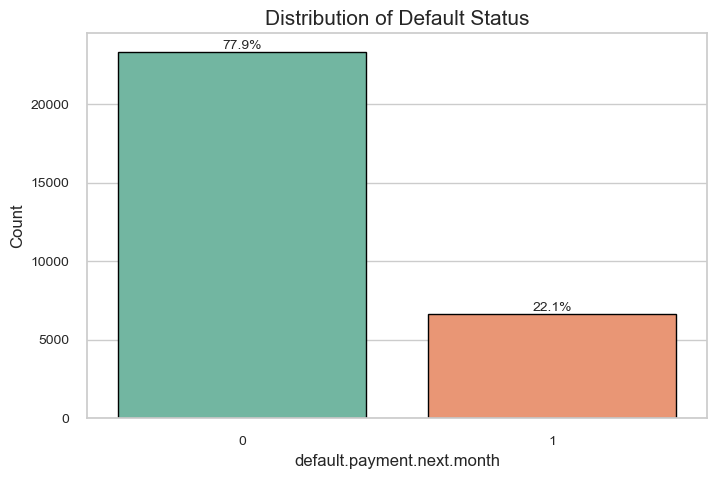

In [11]:
plot_countplot(
    df,
    'default.payment.next.month',
    'Distribution of Default Status'
)

Observation: Approximately 22% of customers defaulted in the following month, while 78% remained non-defaulting. Although the dataset is moderately imbalanced, the default class is sufficiently represented for scorecard development without requiring resampling techniques.

#### Categorical Variables

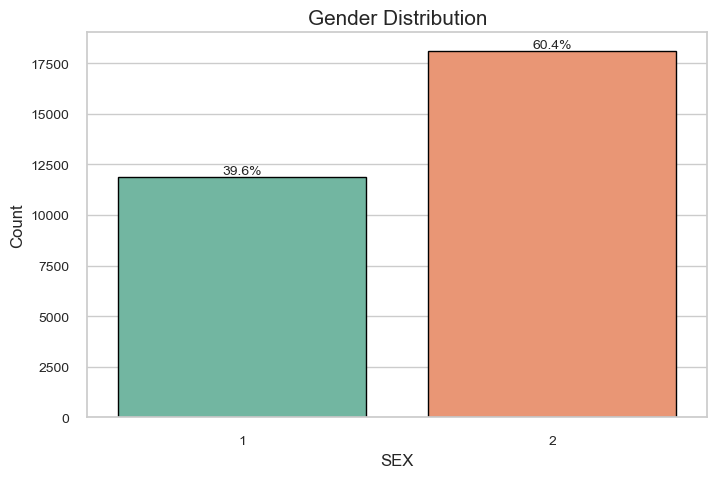

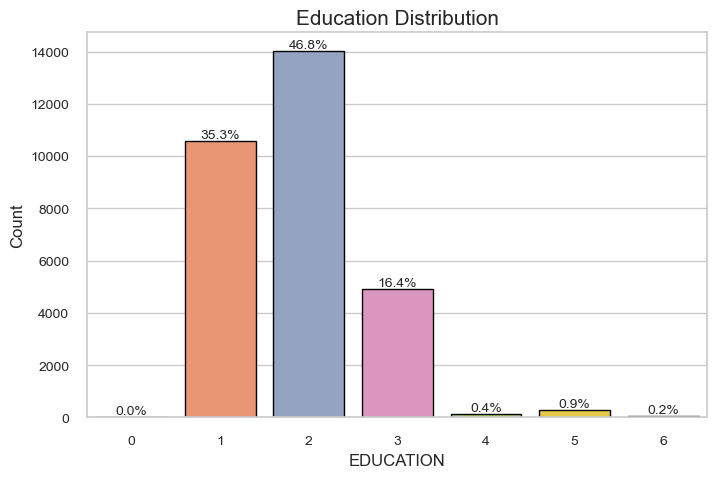

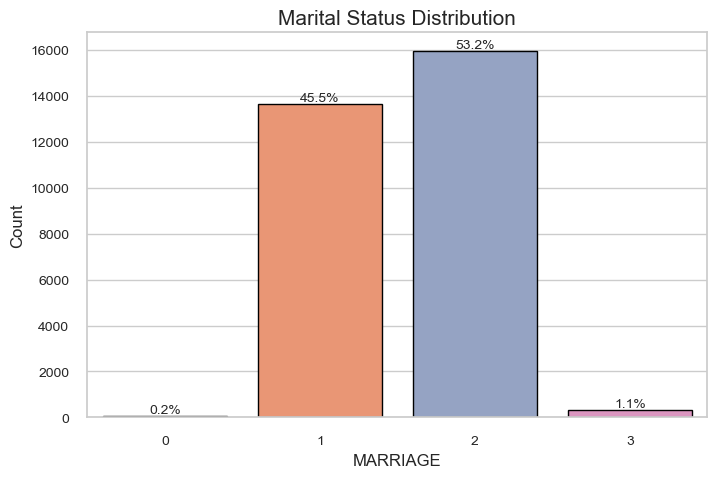

In [12]:
plot_countplot(df,'SEX','Gender Distribution')
plot_countplot(df,'EDUCATION','Education Distribution')
plot_countplot(df,'MARRIAGE','Marital Status Distribution')

- SEX : Female customers constitute a larger proportion of the portfolio than male customers.
- EDUCATION : Most customers have university or graduate-level education. A small number of observations belong to categories 4, 5, and 6, which are undocumented or unknown and will be reviewed during data cleaning.
- MARRIAGE : Most customers are either married or single, with very few observations classified as "others" or category 0.

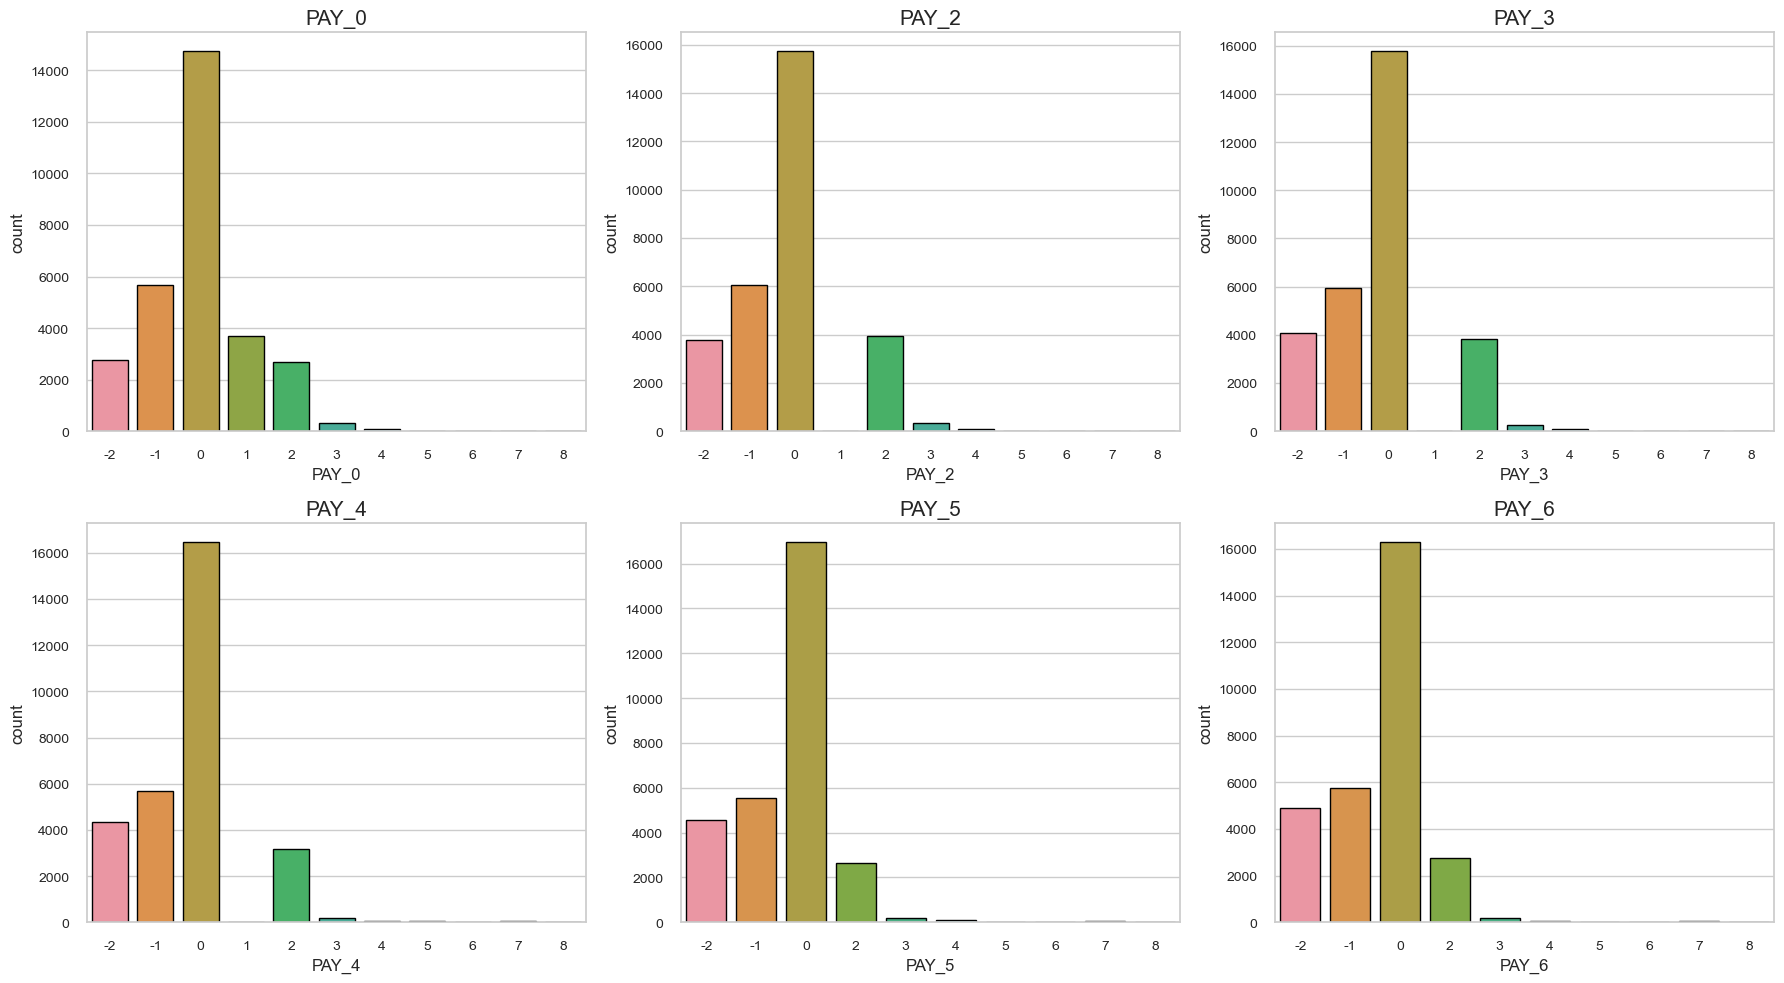

In [13]:
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

fig, axes = plt.subplots(2,3, figsize=(18,10))

for ax, col in zip(axes.flatten(), pay_cols):

    sns.countplot(
        data=df,
        x=col,
        order=sorted(df[col].unique()),
        edgecolor='black',
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

Across all six months, the majority of customers have repayment statuses of -1 or 0, indicating current or timely repayment. Higher delinquency levels (3 months or more overdue) occur infrequently.

#### Numerical Variables

In [14]:
def plot_distribution(data, column):

    fig, axes = plt.subplots(1,2, figsize=(14,4))

    sns.histplot(
        data[column],
        kde=True,
        bins=30,
        ax=axes[0]
    )

    axes[0].set_title(f'{column} Distribution')

    sns.boxplot(
        x=data[column],
        ax=axes[1]
    )

    axes[1].set_title(f'{column} Boxplot')

    plt.tight_layout()
    plt.show()

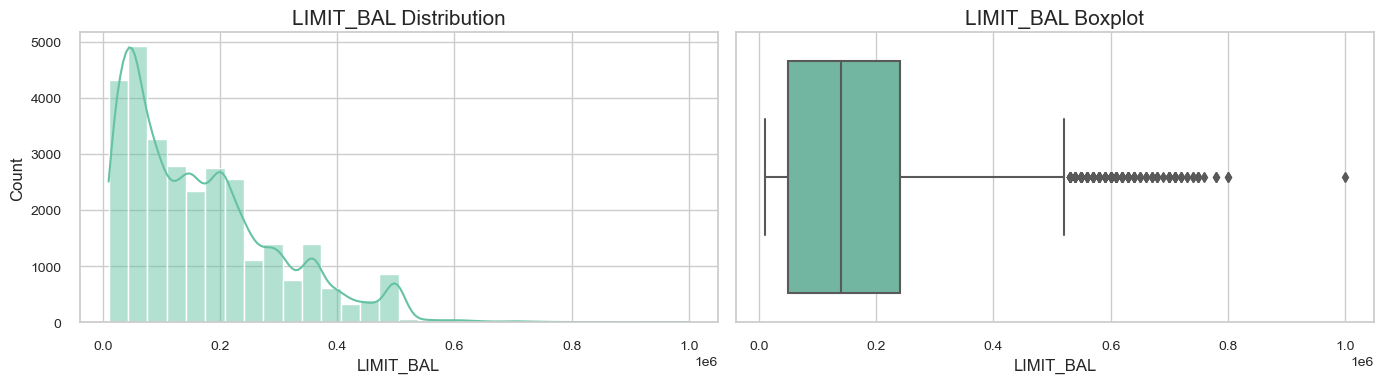

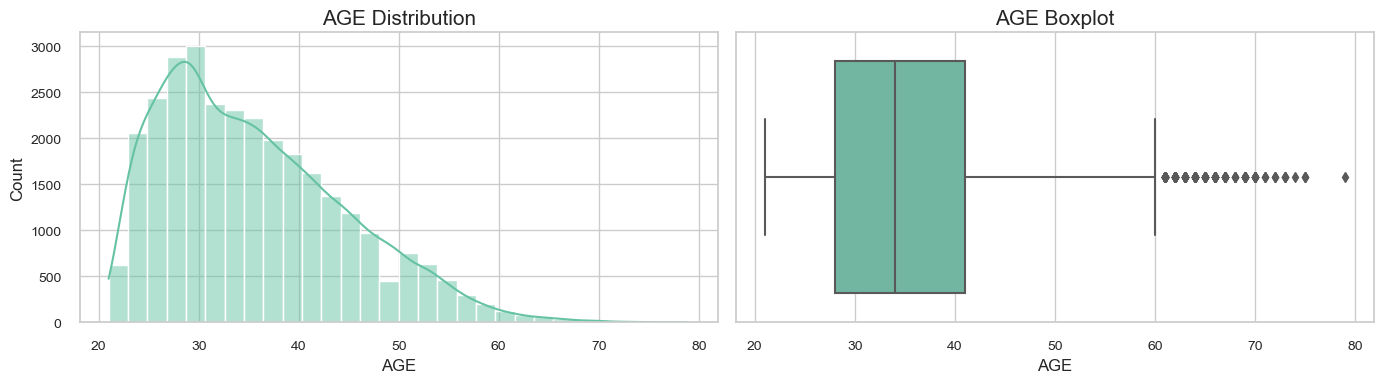

In [15]:
plot_distribution(df,'LIMIT_BAL')
plot_distribution(df,'AGE')

- LIMIT_BAL:The distribution of LIMIT_BAL is positively skewed, indicating that most customers have relatively low to moderate credit limits, while only a small proportion have very high credit limits.The boxplot reveals the presence of several high-value outliers, which likely represent high-income or premium credit card holders.
- AGE : Customer ages range from 21 to 79 years, with the majority concentrated between 25 and 40 years. The distribution exhibits a slight positive skew, suggesting that the portfolio primarily consists of younger to middle-aged customers, while older customers form a relatively small proportion. Although a few higher-age observations appear as outliers in the boxplot, they represent valid customer records and do not warrant removal.

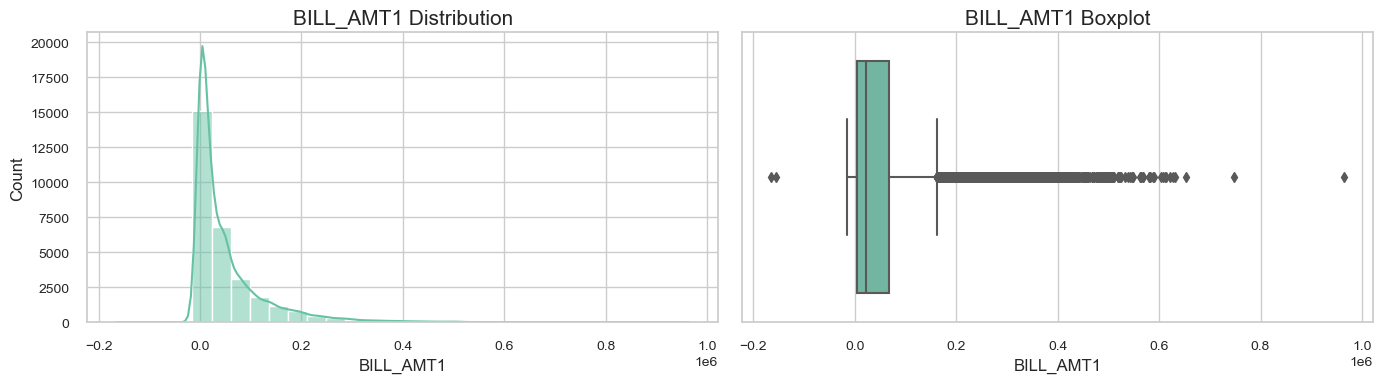

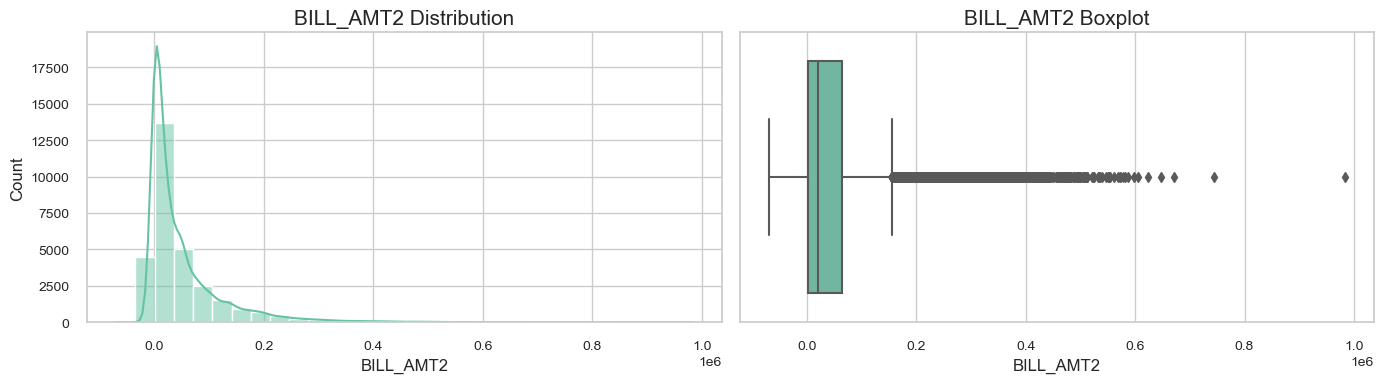

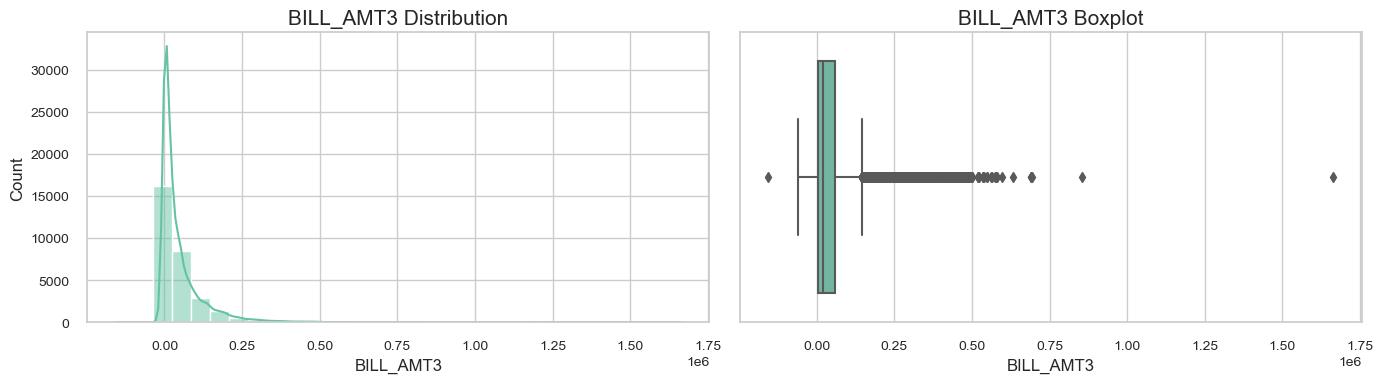

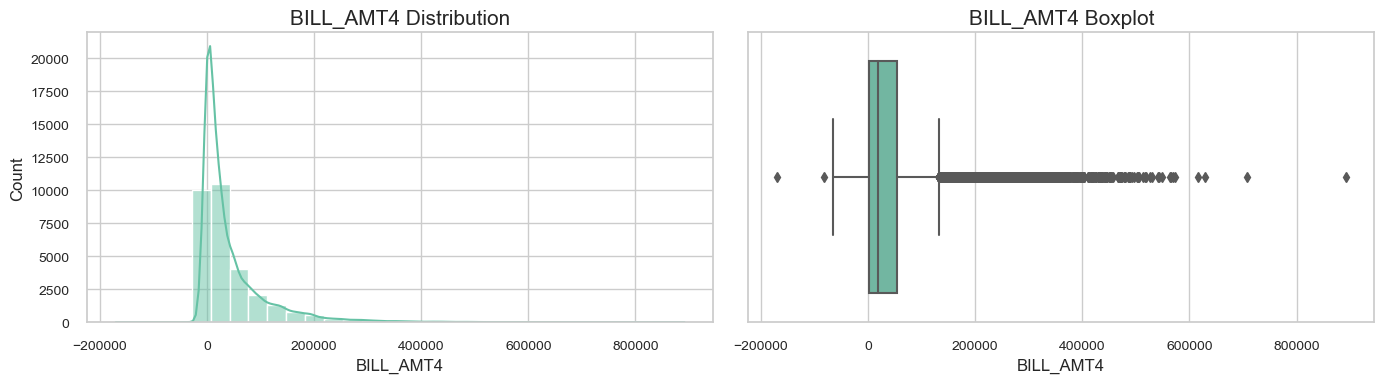

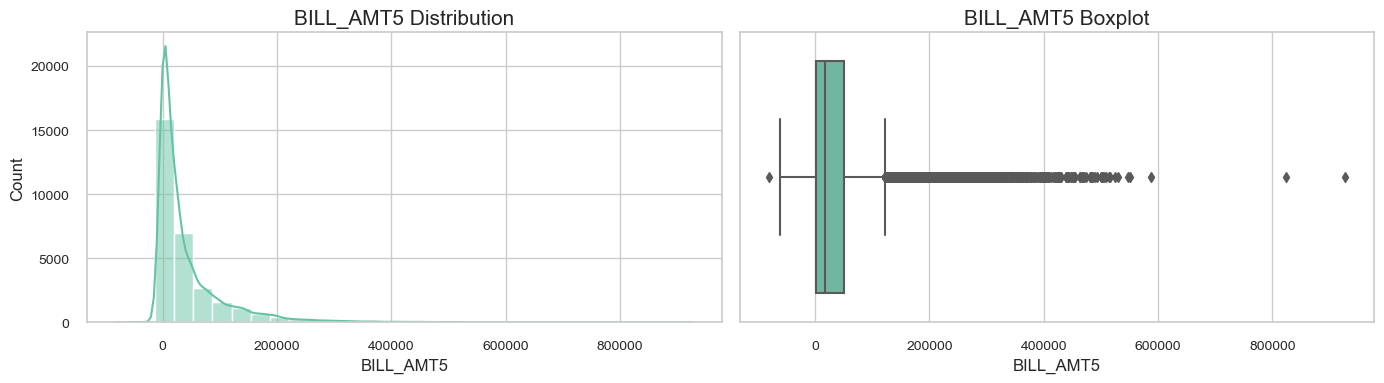

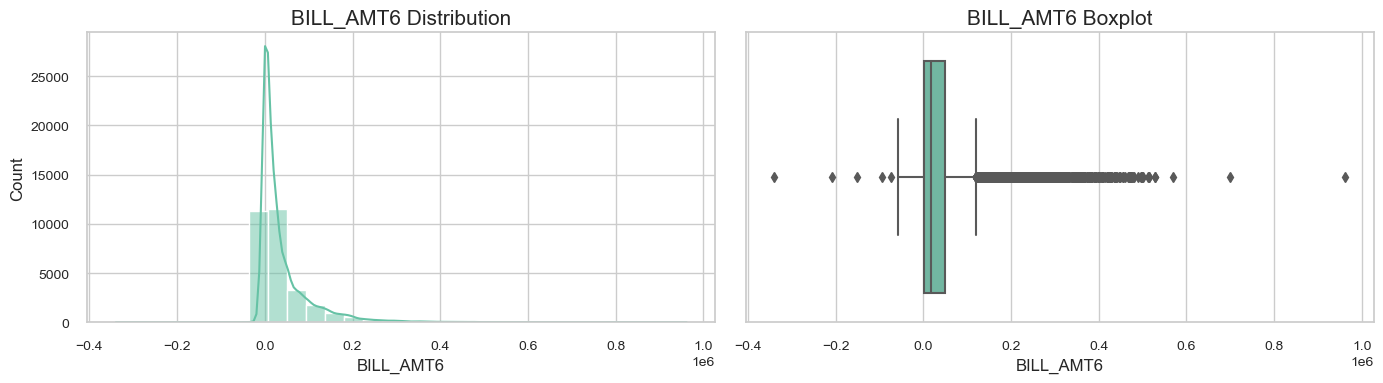

In [16]:
bill_cols = [f'BILL_AMT{i}' for i in range(1,7)]

for col in bill_cols:
    plot_distribution(df,col)

The distributions of all six bill amount variables are highly positively skewed, indicating that the majority of customers maintain relatively low to moderate outstanding balances, while a small proportion carry substantially higher balances. Boxplots reveal the presence of numerous high-value outliers across all billing months, reflecting customers with significantly larger credit utilization. Additionally, a few negative bill amounts are observed, which are likely attributable to credit balances, overpayments, refunds, or billing adjustments rather than data quality issues.

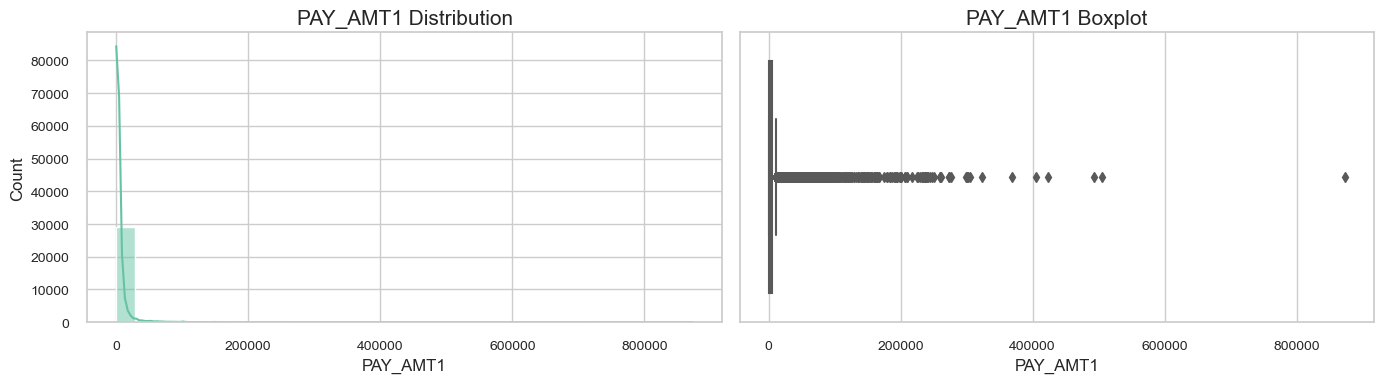

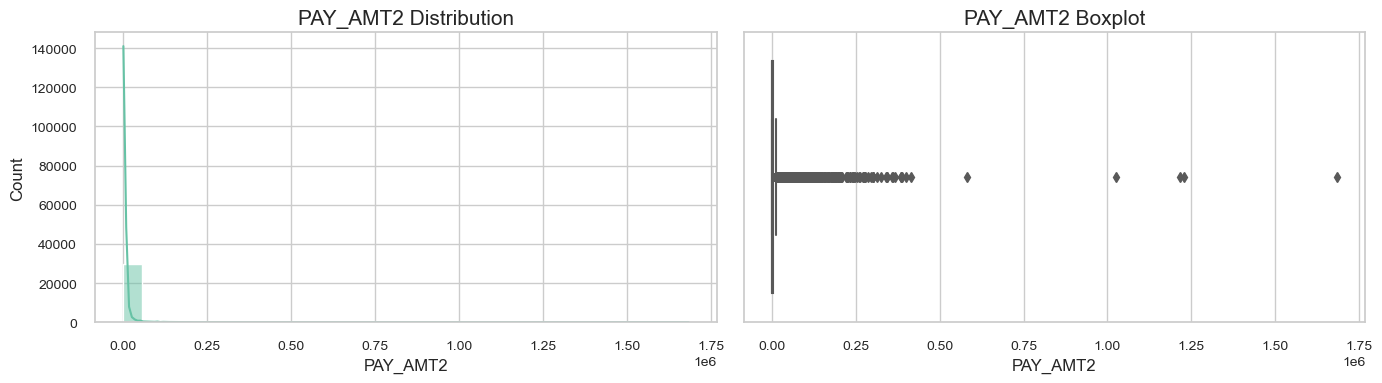

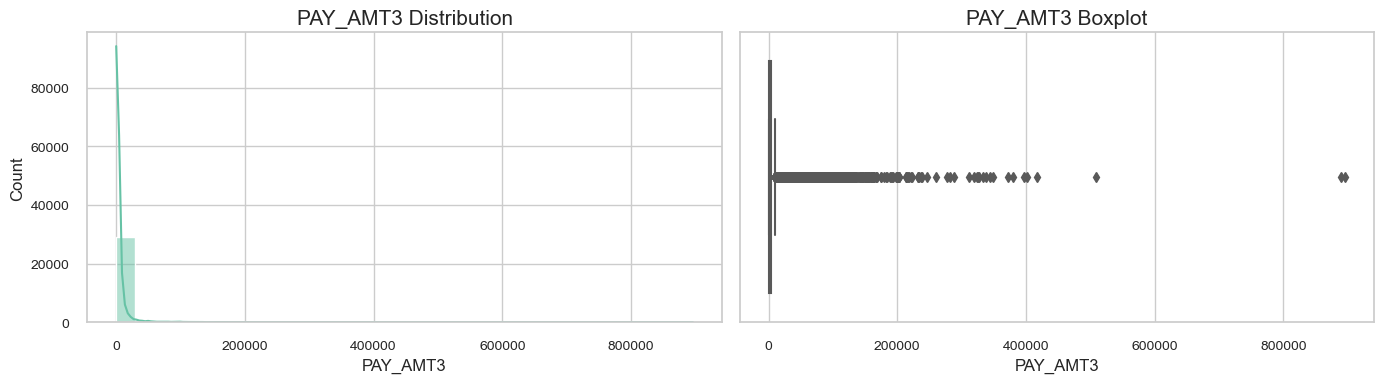

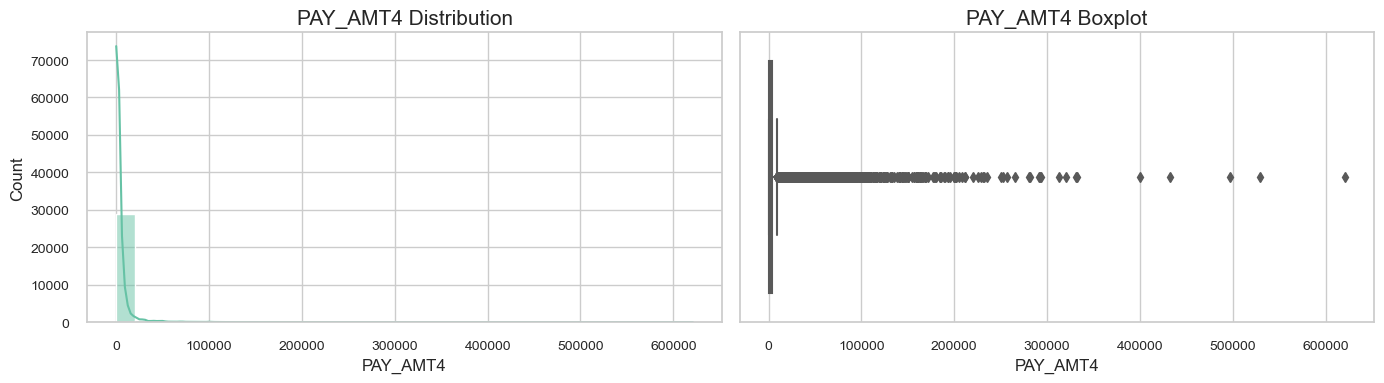

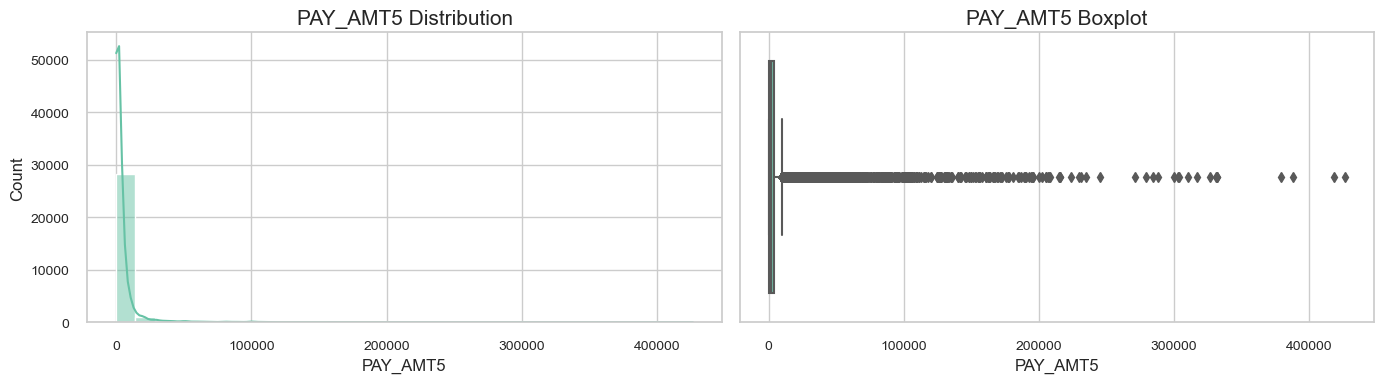

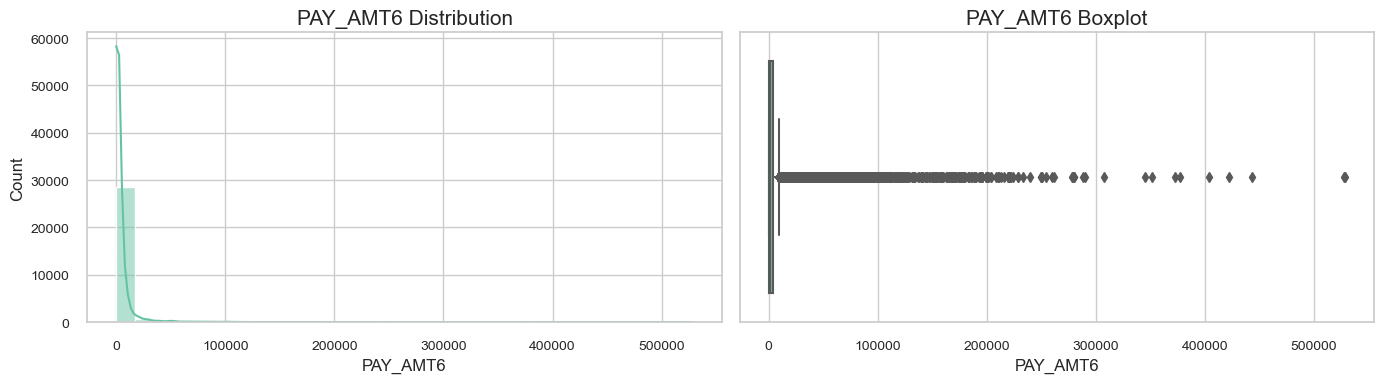

In [17]:
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1,7)]

for col in pay_amt_cols:
    plot_distribution(df,col)

The distributions of the monthly payment amount variables are consistently concentrated around lower repayment values, suggesting that the majority of customers make relatively modest monthly payments. A small proportion of customers exhibit significantly higher payment amounts, resulting in pronounced right-skewness and several high-value outliers.

#### Bivariate Analysis

In [18]:
def plot_default_rate(data, feature, target='default.payment.next.month'):
    
    default_rate = (
        data.groupby(feature)[target]
        .mean()
        .reset_index()
    )

    default_rate[target] *= 100

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        data=default_rate,
        x=feature,
        y=target,
        palette='viridis',
        edgecolor='black'
    )

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x()+p.get_width()/2,
                     p.get_height()),
                    ha='center',
                    va='bottom',
                    fontsize=10)

    plt.ylabel('Default Rate (%)')
    plt.title(f'Default Rate by {feature}')
    plt.show()

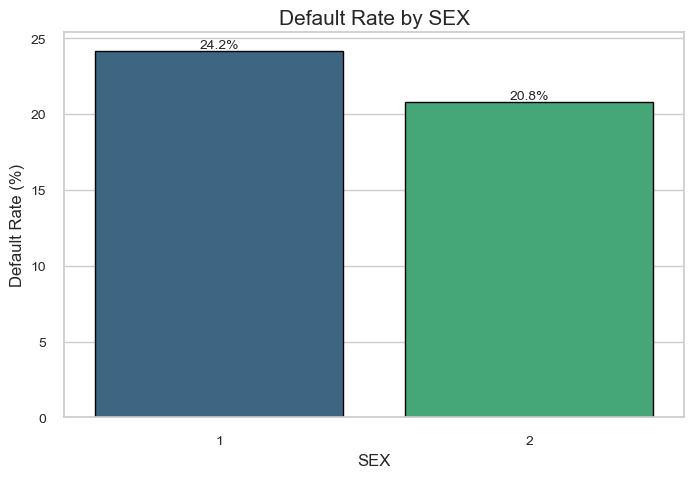

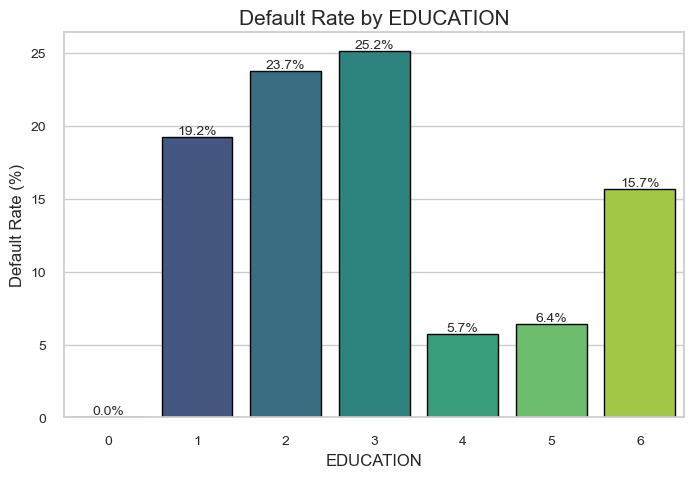

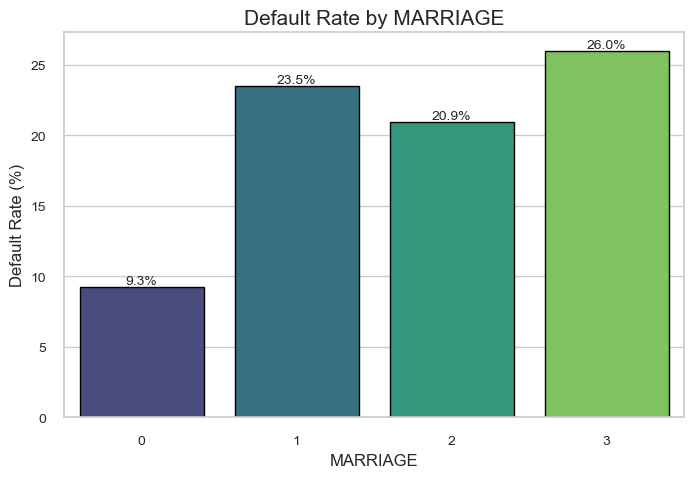

In [19]:
plot_default_rate(df,'SEX')
plot_default_rate(df,'EDUCATION')
plot_default_rate(df,'MARRIAGE')

- SEX : Male customers exhibit a higher default rate (24.2%) compared to female customers (20.8%), suggesting that gender may have some predictive power in distinguishing default behaviour. However, the difference is relatively modest
- EDUCATION : Customers with graduate school (1) and university (2) education account for the majority of the portfolio and exhibit default rates of approximately 19.2% and 23.7%, respectively. Categories 4 (Others) and 5 (Unknown) show considerably lower default rates, while category 6 records a moderate default rate.
- MARRIAGE - Default rates vary across marital status categories, with single customers (1) exhibiting a higher default rate (23.5%) than married customers (2) (20.9%). The 'Others' (3) category records the highest default rate (26.0%);

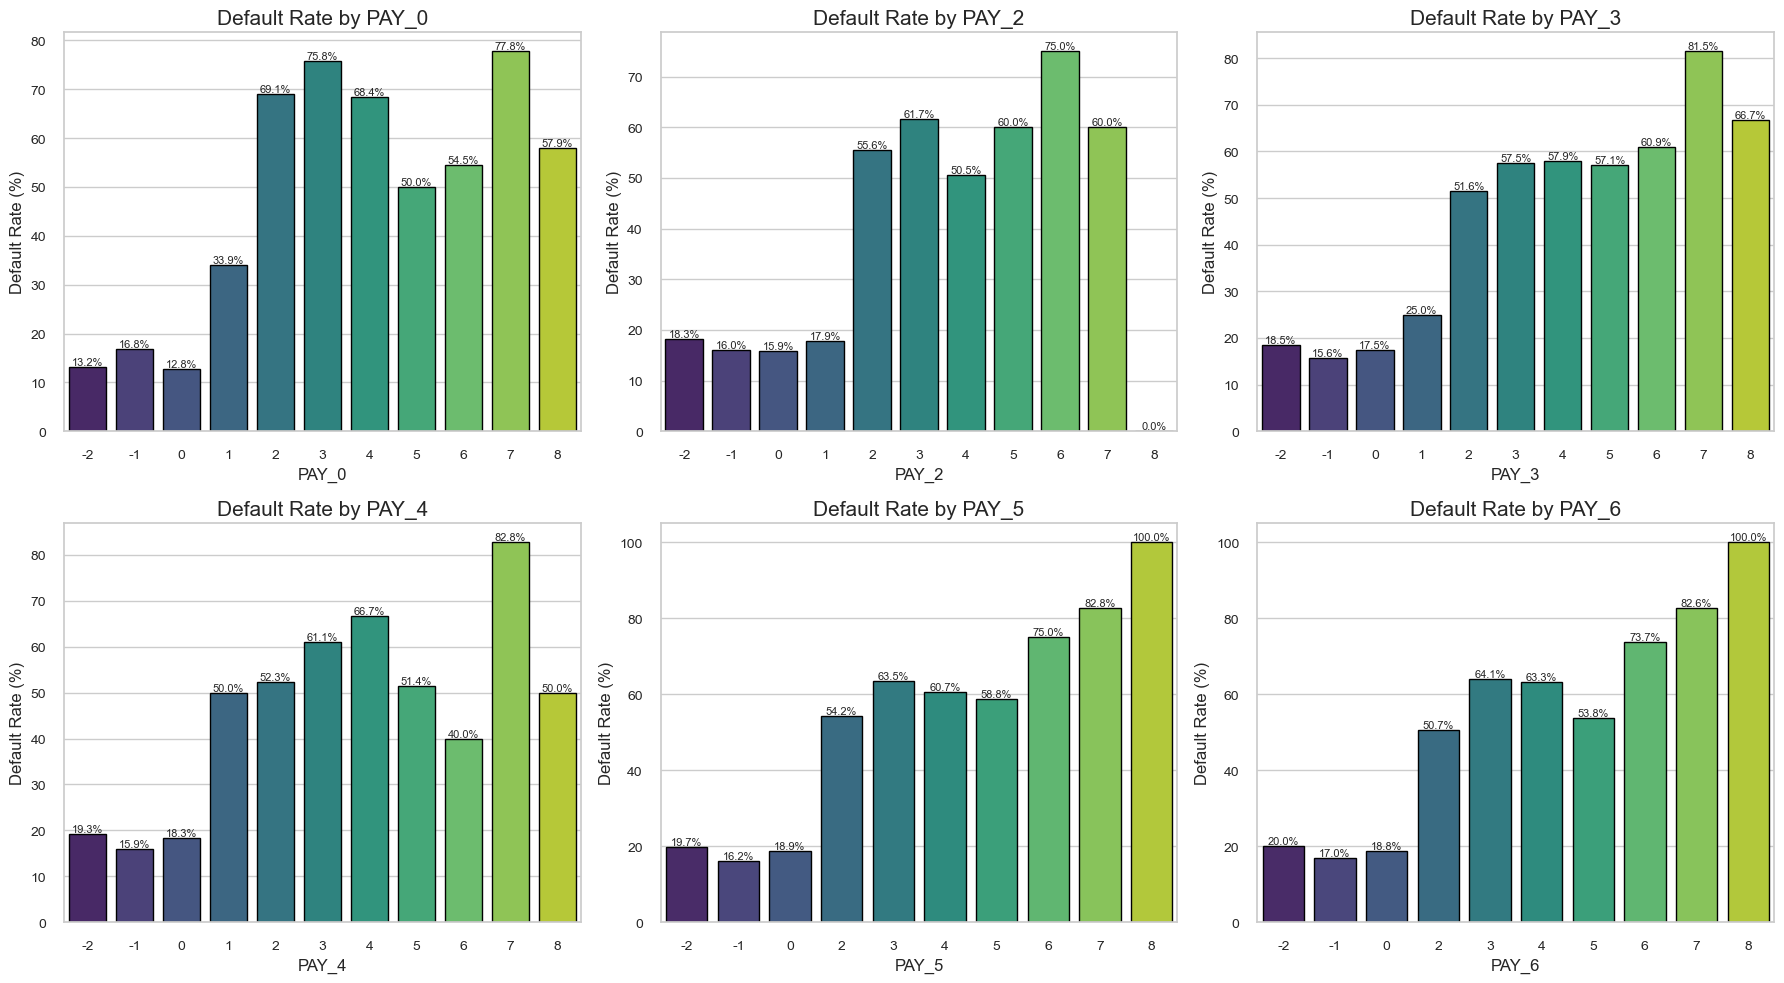

In [20]:
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), pay_cols):

    default_rate = (
        df.groupby(col)['default.payment.next.month']
          .mean()
          .reset_index()
    )

    default_rate['default.payment.next.month'] *= 100

    sns.barplot(
        data=default_rate,
        x=col,
        y='default.payment.next.month',
        edgecolor='black',
        palette='viridis',
        ax=ax
    )

    # Annotate percentages
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x()+p.get_width()/2,
                     p.get_height()),
                    ha='center',
                    va='bottom',
                    fontsize=8)

    ax.set_ylabel('Default Rate (%)')
    ax.set_xlabel(col)
    ax.set_title(f'Default Rate by {col}')

plt.tight_layout()
plt.show()

The repayment status variables (PAY_0–PAY_6) demonstrate a strong relationship with default behaviour. Customers with timely repayments or no payment delay (PAY ≤ 0) consistently exhibit the lowest default rates, while those with one or more months of payment delay (PAY > 0) show substantially higher default rates. Although minor fluctuations are observed in the highest delinquency categories due to the relatively small number of observations, the overall trend indicates that the likelihood of default generally increases with worsening repayment status.

#### Multivariate Analysis

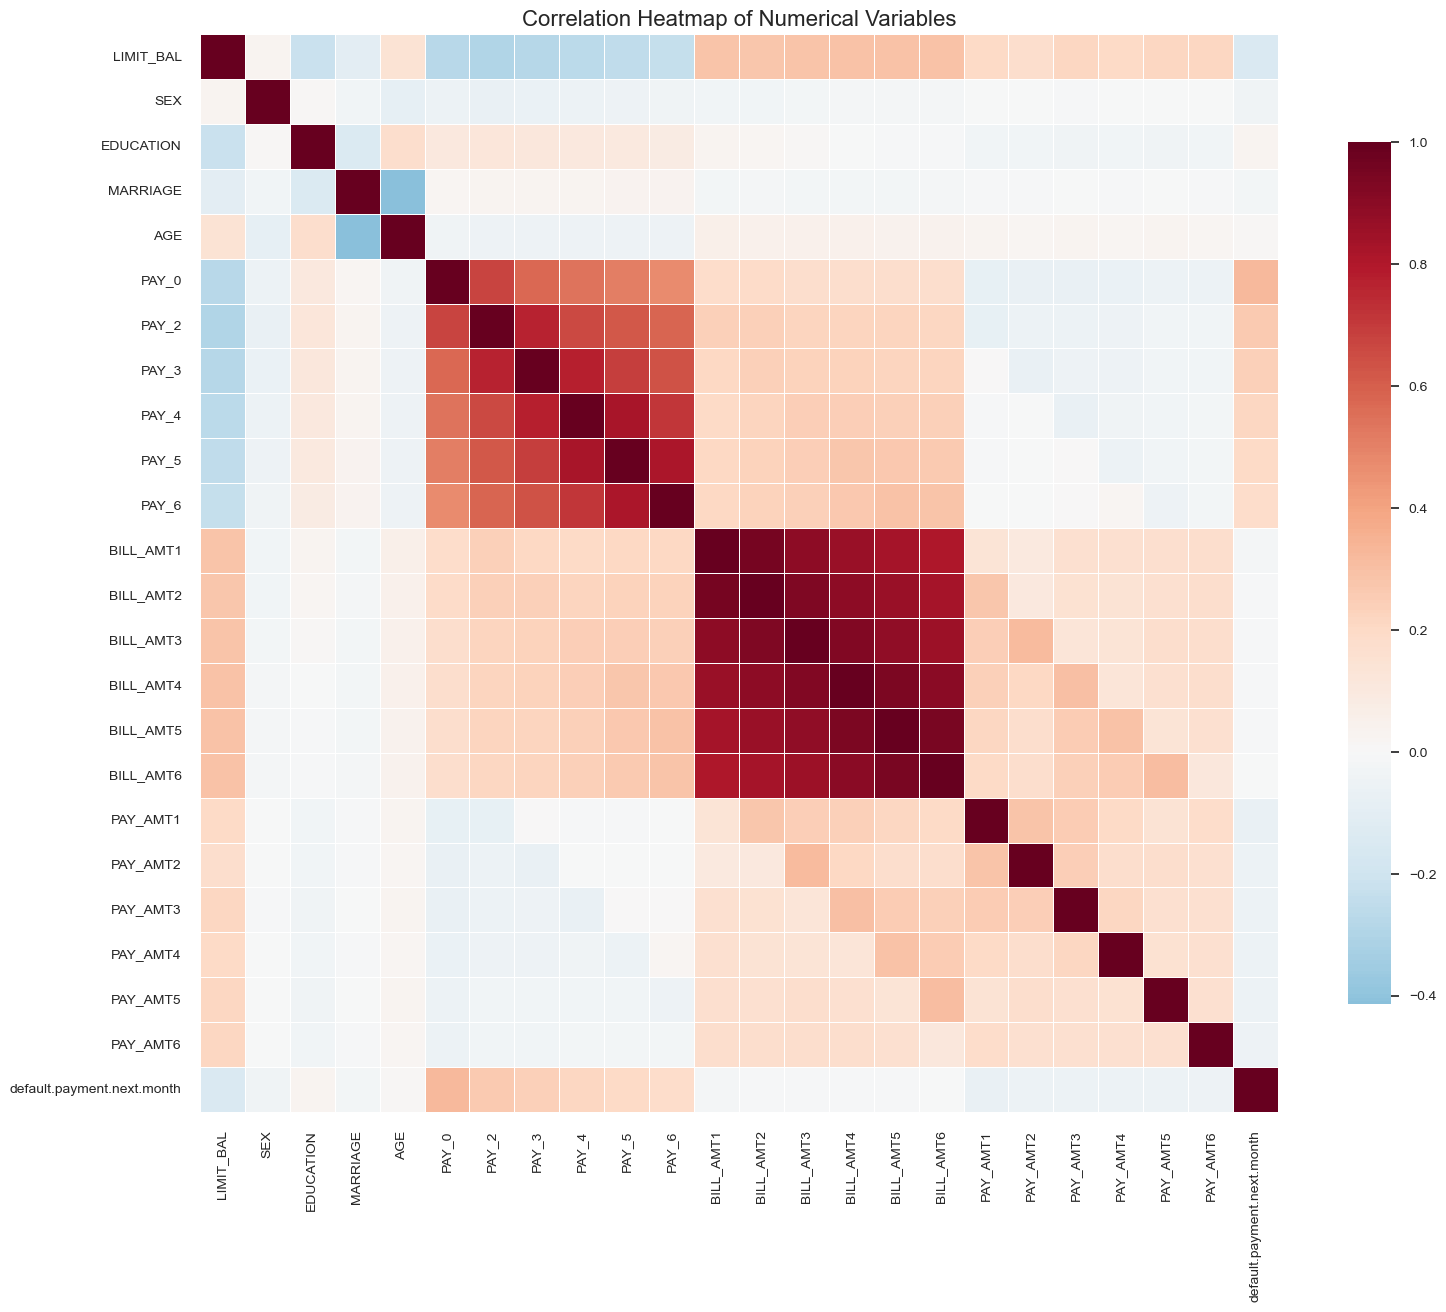

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop ID as it is just an identifier
corr = df.drop(columns=['ID']).corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap='RdBu_r',
    center=0,
    annot=False,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.show()

The correlation heatmap reveals strong positive correlations among the monthly bill amount variables (BILL_AMT1–BILL_AMT6) and among the repayment status variables (PAY_0–PAY_6), indicating that customer billing and repayment behaviour remains relatively consistent across consecutive months. Moderate correlations are also observed among the monthly payment amount variables (PAY_AMT1–PAY_AMT6). Correlations between demographic variables and the target variable are relatively weak, whereas repayment status variables exhibit the strongest positive association with default. The high correlations within the bill amount and repayment status groups suggest the presence of multicollinearity

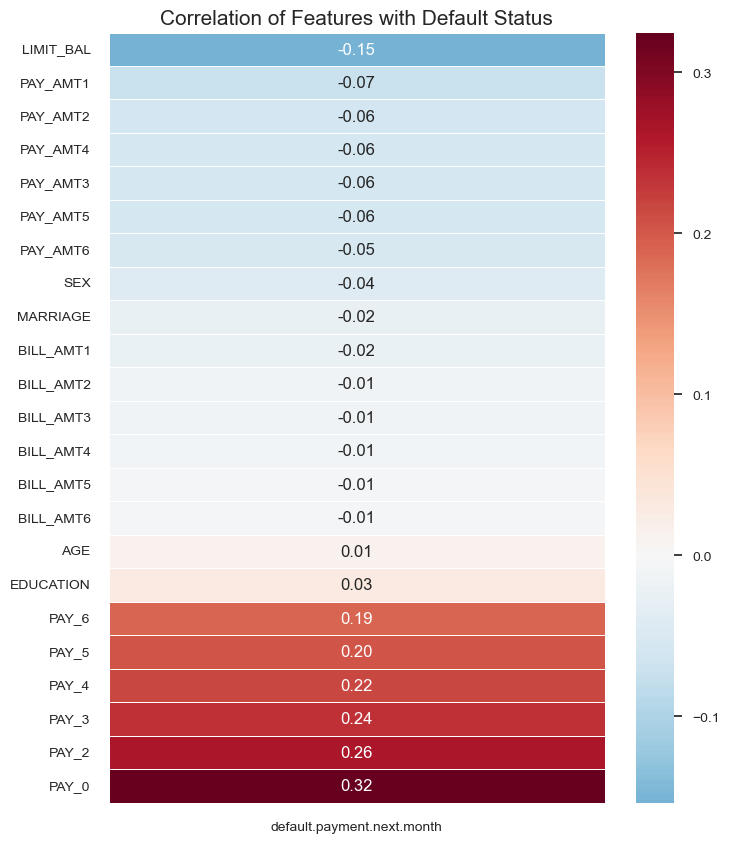

In [22]:
target_corr = (
    df.drop(columns='ID')
      .corr()['default.payment.next.month']
      .drop('default.payment.next.month')
      .sort_values()
)

plt.figure(figsize=(8,10))

sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation of Features with Default Status')
plt.show()

The correlation analysis indicates that the repayment status variables (PAY_0–PAY_6) exhibit the strongest positive association with default, with PAY_0 showing the highest correlation (0.32), followed by PAY_2 (0.26) and PAY_3 (0.24). This highlights recent repayment behaviour as the most influential indicator of future default risk. Conversely, LIMIT_BAL exhibits the strongest negative correlation (-0.15), suggesting that customers with higher credit limits tend to have a lower likelihood of default. The remaining demographic, bill amount, and payment amount variables display relatively weak linear correlations with the target.

### Data Preprocessing & Feature Engineering

#### Drop Identifier

In [23]:
df = df.drop(columns='ID')

#### Handling Invalid Categories

In [24]:
df['EDUCATION'] = df['EDUCATION'].replace({
    0:4,
    5:4,
    6:4
})

Official documentation marks 5 and 6 as unknown. 0 is undocumented.

In [25]:
df['MARRIAGE'] = df['MARRIAGE'].replace({
    0:3
})

Category 0 is undocumented.

### Train - Test Split

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='default.payment.next.month')
y = df['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

### Fine Classing

#### Classify Variables

In [27]:
categorical_cols = [
    'SEX',
    'EDUCATION',
    'MARRIAGE',
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

continuous_cols = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6',
    'PAY_AMT1',
    'PAY_AMT2',
    'PAY_AMT3',
    'PAY_AMT4',
    'PAY_AMT5',
    'PAY_AMT6'
]

#### Fine Classing Continuous Variables

In [28]:
train_df = X_train.copy()
train_df['TARGET'] = y_train

bin_edges = {}

for col in continuous_cols:

    train_df[col + '_BIN'], bin_edges[col] = pd.qcut(
        train_df[col],
        q=10,
        duplicates='drop',
        retbins=True
    )

In [29]:
train_df = X_train.copy()
train_df['TARGET'] = y_train

In [30]:
test_df=X_test.copy()
test_df['TARGET'] = y_test

In [31]:
train_df['LIMIT_BAL_BIN'] = pd.qcut(
    train_df['LIMIT_BAL'],
    q=10,
    duplicates='drop'
)

In [32]:
fine_class = (
    train_df
    .groupby('LIMIT_BAL_BIN')
    .agg(
        Total=('TARGET', 'count'),
        Bad=('TARGET', 'sum')
    )
)

fine_class['Good'] = fine_class['Total'] - fine_class['Bad']
fine_class['Bad Rate'] = fine_class['Bad'] / fine_class['Total']

fine_class

,Total,Bad,Good,Bad Rate
LIMIT_BAL_BIN,,,,
"(9999.999, 30000.0]",2864,1057,1807,0.37
"(30000.0, 50000.0]",2513,671,1842,0.27
"(50000.0, 70000.0]",1085,314,771,0.29
"(70000.0, 100000.0]",2262,544,1718,0.24
"(100000.0, 140000.0]",1950,458,1492,0.23
"(140000.0, 180000.0]",2346,402,1944,0.17
"(180000.0, 210000.0]",1781,318,1463,0.18
"(210000.0, 270000.0]",2058,335,1723,0.16
"(270000.0, 360000.0]",2419,347,2072,0.14


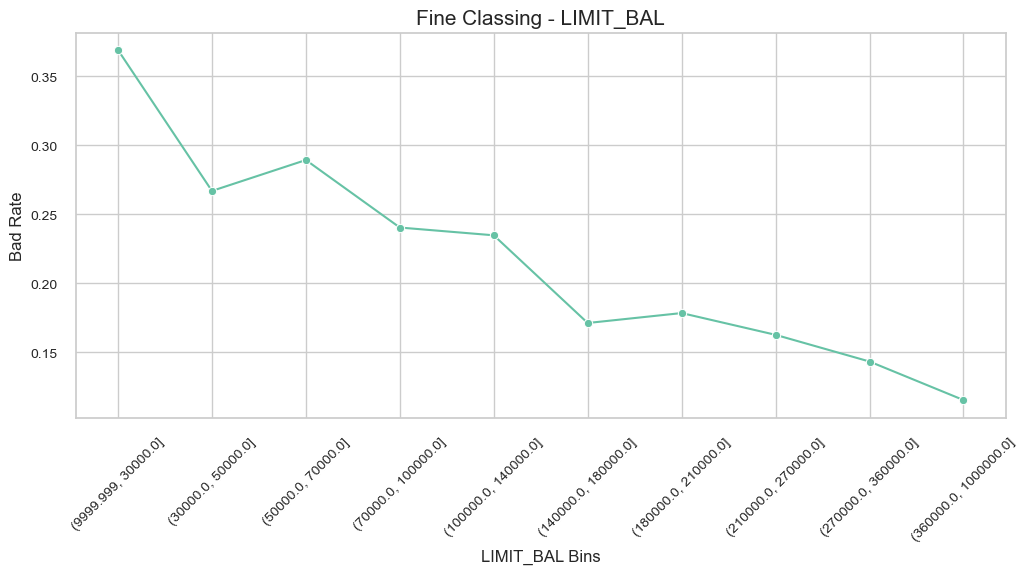

In [33]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=fine_class.index.astype(str),
    y=fine_class['Bad Rate'],
    marker='o'
)

plt.xticks(rotation=45)
plt.ylabel("Bad Rate")
plt.xlabel("LIMIT_BAL Bins")
plt.title("Fine Classing - LIMIT_BAL")

plt.show()

Performing Coarse Classing to get monotonic bad rate

In [34]:
train_df['LIMIT_BAL_COARSE'] = pd.cut(
    train_df['LIMIT_BAL'],
    bins=[0,
          30000,
          70000,
          140000,
          210000,
          360000,
          train_df['LIMIT_BAL'].max()],
    include_lowest=True
)

In [35]:
coarse_class = (
    train_df
    .groupby('LIMIT_BAL_COARSE')
    .agg(
        Total=('TARGET','count'),
        Bad=('TARGET','sum')
    )
)

coarse_class['Good'] = coarse_class['Total'] - coarse_class['Bad']
coarse_class['Bad Rate'] = coarse_class['Bad'] / coarse_class['Total']

coarse_class

,Total,Bad,Good,Bad Rate
LIMIT_BAL_COARSE,,,,
"(-0.001, 30000.0]",2864,1057,1807,0.37
"(30000.0, 70000.0]",3598,985,2613,0.27
"(70000.0, 140000.0]",4212,1002,3210,0.24
"(140000.0, 210000.0]",4127,720,3407,0.17
"(210000.0, 360000.0]",4477,682,3795,0.15
"(360000.0, 1000000.0]",1722,199,1523,0.12


After coarse classing, the bad rate exhibits a clear monotonic decreasing trend across the credit limit bins. Customers with lower sanctioned credit limits demonstrate substantially higher default rates, while customers with higher credit limits exhibit progressively lower default rates.

In [36]:
# Total good and bad customers in the training set
total_good = coarse_class['Good'].sum()
total_bad = coarse_class['Bad'].sum()

coarse_class['Good %'] = coarse_class['Good'] / total_good
coarse_class['Bad %'] = coarse_class['Bad'] / total_bad

coarse_class

,Total,Bad,Good,Bad Rate,Good %,Bad %
LIMIT_BAL_COARSE,,,,,,
"(-0.001, 30000.0]",2864,1057,1807,0.37,0.11,0.23
"(30000.0, 70000.0]",3598,985,2613,0.27,0.16,0.21
"(70000.0, 140000.0]",4212,1002,3210,0.24,0.20,0.22
"(140000.0, 210000.0]",4127,720,3407,0.17,0.21,0.16
"(210000.0, 360000.0]",4477,682,3795,0.15,0.23,0.15
"(360000.0, 1000000.0]",1722,199,1523,0.12,0.09,0.04


In [37]:
#WOE=ln(Good%/Bad%)

coarse_class['WOE'] = np.log(
    coarse_class['Good %'] /
    coarse_class['Bad %']
)

In [38]:
#IVi =(Good%−Bad%)×WOE
coarse_class['IV'] = (
    (coarse_class['Good %'] - coarse_class['Bad %'])
    * coarse_class['WOE']
)

In [39]:
total_iv = coarse_class['IV'].sum()

print(f"Information Value : {total_iv:.4f}")

Information Value : 0.1950


LIMIT_BAL demonstrates moderate predictive power in distinguishing between defaulting and non-defaulting customers

In [40]:
coarse_class

,Total,Bad,Good,Bad Rate,Good %,Bad %,WOE,IV
LIMIT_BAL_COARSE,,,,,,,,
"(-0.001, 30000.0]",2864,1057,1807,0.37,0.11,0.23,-0.72,0.08
"(30000.0, 70000.0]",3598,985,2613,0.27,0.16,0.21,-0.28,0.01
"(70000.0, 140000.0]",4212,1002,3210,0.24,0.20,0.22,-0.09,0.00
"(140000.0, 210000.0]",4127,720,3407,0.17,0.21,0.16,0.30,0.02
"(210000.0, 360000.0]",4477,682,3795,0.15,0.23,0.15,0.46,0.04
"(360000.0, 1000000.0]",1722,199,1523,0.12,0.09,0.04,0.78,0.04


Following coarse classing, the Weight of Evidence (WOE) values exhibit a clear monotonic increasing trend, with lower credit limit bins associated with negative WOE values and higher credit limit bins associated with positive WOE values. This indicates that customers with lower sanctioned credit limits are more likely to default, whereas customers with higher credit limits are relatively lower risk. The total Information Value (IV) of approximately 0.19 suggests that LIMIT_BAL has moderate predictive strength and is an appropriate predictor for the Probability of Default (PD) scorecard.

#### Create a Generic WOE Function

In [41]:
def calculate_woe_iv(data, feature, target='TARGET'):
    
    woe_table = (
        data.groupby(feature)
        .agg(
            Total=(target, 'count'),
            Bad=(target, 'sum')
        )
        .reset_index()
    )

    woe_table['Good'] = woe_table['Total'] - woe_table['Bad']

    total_good = woe_table['Good'].sum()
    total_bad = woe_table['Bad'].sum()

    woe_table['Good %'] = woe_table['Good'] / total_good
    woe_table['Bad %'] = woe_table['Bad'] / total_bad

    # Avoid division by zero
    woe_table['Good %'] = woe_table['Good %'].replace(0, 0.0001)
    woe_table['Bad %'] = woe_table['Bad %'].replace(0, 0.0001)

    woe_table['WOE'] = np.log(
        woe_table['Good %'] /
        woe_table['Bad %']
    )

    woe_table['IV'] = (
        (woe_table['Good %'] - woe_table['Bad %'])
        * woe_table['WOE']
    )

    total_iv = woe_table['IV'].sum()

    return woe_table, total_iv

In [42]:
woe_table, iv = calculate_woe_iv(
    train_df,
    'LIMIT_BAL_COARSE'
)

display(woe_table)

print(iv)

,LIMIT_BAL_COARSE,Total,Bad,Good,Good %,Bad %,WOE,IV
0,"(-0.001, 30000.0]",2864,1057,1807,0.11,0.23,-0.72,0.08
1,"(30000.0, 70000.0]",3598,985,2613,0.16,0.21,-0.28,0.01
2,"(70000.0, 140000.0]",4212,1002,3210,0.20,0.22,-0.09,0.00
3,"(140000.0, 210000.0]",4127,720,3407,0.21,0.16,0.30,0.02
4,"(210000.0, 360000.0]",4477,682,3795,0.23,0.15,0.46,0.04
5,"(360000.0, 1000000.0]",1722,199,1523,0.09,0.04,0.78,0.04


0.19502052590443472


#### Create a Generic IV Function

In [43]:
def iv_strength(iv):

    if iv < 0.02:
        return "Not Predictive"

    elif iv < 0.10:
        return "Weak"

    elif iv < 0.30:
        return "Medium"

    elif iv < 0.50:
        return "Strong"

    else:
        return "Very Strong"

In [44]:
print(iv_strength(iv))

Medium


In [45]:
train_num = train_df.copy()

In [46]:
for col in continuous_cols:

    train_num[col + '_BIN'] = pd.qcut(
        train_num[col],
        q=10,
        duplicates='drop'
    )

In [47]:
continuous_iv = []

continuous_woe_tables = {}

for col in continuous_cols:

    table, iv = calculate_woe_iv(
        train_num,
        col + '_BIN'
    )

    continuous_woe_tables[col] = table

    continuous_iv.append({
        'Variable': col,
        'IV': round(iv,4),
        'Strength': iv_strength(iv)
    })

In [48]:
continuous_iv = pd.DataFrame(continuous_iv)

continuous_iv = continuous_iv.sort_values(
    by='IV',
    ascending=False
)

continuous_iv

,Variable,IV,Strength
0,LIMIT_BAL,0.20,Medium
8,PAY_AMT1,0.16,Medium
9,PAY_AMT2,0.15,Medium
10,PAY_AMT3,0.13,Medium
13,PAY_AMT6,0.09,Weak
11,PAY_AMT4,0.08,Weak
12,PAY_AMT5,0.08,Weak
7,BILL_AMT6,0.02,Weak
1,AGE,0.02,Not Predictive
3,BILL_AMT2,0.02,Not Predictive


In [49]:
iv_summary = []

woe_tables = {}

for col in categorical_cols:

    table, iv = calculate_woe_iv(train_df, col)

    woe_tables[col] = table

    iv_summary.append({
        'Variable': col,
        'IV': round(iv,4),
        'Strength': iv_strength(iv)
    })

iv_summary = pd.DataFrame(iv_summary)

iv_summary = iv_summary.sort_values(
    by='IV',
    ascending=False
)

iv_summary

,Variable,IV,Strength
3,PAY_0,0.90,Very Strong
4,PAY_2,0.56,Very Strong
5,PAY_3,0.42,Strong
6,PAY_4,0.37,Strong
7,PAY_5,0.35,Strong
8,PAY_6,0.30,Strong
1,EDUCATION,0.04,Weak
0,SEX,0.01,Not Predictive
2,MARRIAGE,0.00,Not Predictive


The Information Value (IV) analysis indicates that the repayment status variables (PAY_0–PAY_6) possess the highest predictive power for distinguishing defaulting and non-defaulting customers. PAY_0 demonstrates the strongest predictive ability (IV = 0.90), followed by PAY_2 (IV = 0.56), highlighting the importance of recent repayment behaviour in predicting future default. PAY_3–PAY_6 also exhibit strong predictive strength. In contrast, demographic variables such as SEX, MARRIAGE, and EDUCATION contribute relatively little predictive information, with IV values indicating weak or negligible discriminatory power.

In [50]:
final_iv = pd.concat(
    [iv_summary, continuous_iv],
    ignore_index=True
)

final_iv = final_iv.sort_values(
    by='IV',
    ascending=False
)

final_iv.reset_index(drop=True, inplace=True)

final_iv

,Variable,IV,Strength
0,PAY_0,0.90,Very Strong
1,PAY_2,0.56,Very Strong
2,PAY_3,0.42,Strong
3,PAY_4,0.37,Strong
4,PAY_5,0.35,Strong
5,PAY_6,0.30,Strong
6,LIMIT_BAL,0.20,Medium
7,PAY_AMT1,0.16,Medium
8,PAY_AMT2,0.15,Medium
9,PAY_AMT3,0.13,Medium


The Information Value (IV) analysis demonstrates that repayment behaviour variables (PAY_0–PAY_6) possess the highest predictive power, with PAY_0 emerging as the single strongest predictor of default (IV = 0.90). LIMIT_BAL exhibits moderate predictive strength, while recent payment amount variables (PAY_AMT1–PAY_AMT3) provide additional discriminatory power. In contrast, demographic characteristics and bill amount variables contribute relatively little information individually. These findings indicate that recent repayment behaviour is the primary driver of default risk in the portfolio.

### WOE Transformation

#### Continuous variables

In [51]:
train_df = X_train.copy()
train_df['TARGET'] = y_train

bin_edges = {}

for col in continuous_cols:

    train_df[col + '_BIN'], edges = pd.qcut(
        train_df[col],
        q=10,
        duplicates='drop',
        retbins=True
    )

    bin_edges[col] = edges

In [52]:
continuous_woe_tables = {}

for col in continuous_cols:

    table, iv = calculate_woe_iv(
        train_df,
        feature=col + '_BIN'
    )

    continuous_woe_tables[col] = table

In [53]:
continuous_woe_dict = {}

for col in continuous_cols:

    table = continuous_woe_tables[col]

    continuous_woe_dict[col] = dict(
        zip(
            table[col + '_BIN'],
            table['WOE']
        )
    )

In [54]:
X_train_woe = pd.DataFrame(index=X_train.index)

for col in continuous_cols:

    X_train_woe[col + '_WOE'] = (
        train_df[col + '_BIN']
        .map(continuous_woe_dict[col])
    )

In [55]:
X_train_woe

,LIMIT_BAL_WOE,AGE_WOE,BILL_AMT1_WOE,BILL_AMT2_WOE,BILL_AMT3_WOE,BILL_AMT4_WOE,BILL_AMT5_WOE,BILL_AMT6_WOE,PAY_AMT1_WOE,PAY_AMT2_WOE,PAY_AMT3_WOE,PAY_AMT4_WOE,PAY_AMT5_WOE,PAY_AMT6_WOE
11018,0.32,0.14,0.19,0.16,0.17,0.14,0.12,0.15,0.41,0.33,0.38,0.39,0.27,0.36
1710,-0.11,0.16,-0.16,-0.19,-0.07,0.02,0.00,0.01,0.41,0.44,0.38,-0.31,0.08,0.04
4618,-0.11,0.12,0.08,0.04,0.02,-0.12,0.00,0.01,0.12,0.06,-0.09,0.01,-0.00,0.04
5482,-0.72,0.09,-0.02,0.13,0.01,-0.03,-0.07,-0.01,-0.01,-0.01,-0.51,-0.31,-0.29,-0.30
26187,-0.25,0.16,-0.11,0.13,-0.03,-0.03,-0.07,-0.01,0.01,-0.53,-0.51,-0.31,-0.29,-0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25780,0.27,0.14,-0.02,-0.02,-0.03,-0.03,-0.07,-0.01,-0.60,-0.53,-0.51,-0.31,-0.29,-0.30
13921,-0.08,-0.26,0.13,0.13,0.12,0.08,0.12,0.15,0.12,0.04,0.33,0.39,0.32,-0.30
3794,-0.08,-0.26,0.08,0.04,0.02,0.02,-0.11,-0.22,0.12,0.06,0.03,0.01,-0.09,-0.16
27565,0.53,-0.16,-0.11,-0.02,0.01,-0.07,-0.07,-0.01,-0.60,-0.01,-0.06,-0.31,-0.29,-0.30


Continuous variables were initially fine-classed into deciles using quantile binning. Manual coarse classing was demonstrated on LIMIT_BAL to illustrate the methodology. For the remaining continuous variables, the fine classes were retained for WOE transformation due to their satisfactory discriminatory power.

In [56]:
for col in continuous_cols:

    edges = bin_edges[col].copy()

    test_df[col + '_BIN'] = pd.cut(
        test_df[col],
        bins=edges,
        include_lowest=True
    )

In [57]:
X_test_woe = pd.DataFrame(index=X_test.index)

for col in continuous_cols:

    X_test_woe[col + '_WOE'] = (
        test_df[col + '_BIN']
        .map(continuous_woe_dict[col])
    )

In [58]:
X_test_woe

,LIMIT_BAL_WOE,AGE_WOE,BILL_AMT1_WOE,BILL_AMT2_WOE,BILL_AMT3_WOE,BILL_AMT4_WOE,BILL_AMT5_WOE,BILL_AMT6_WOE,PAY_AMT1_WOE,PAY_AMT2_WOE,PAY_AMT3_WOE,PAY_AMT4_WOE,PAY_AMT5_WOE,PAY_AMT6_WOE
8941,0.38,0.16,0.13,0.13,0.12,0.02,0.00,0.01,0.41,0.04,0.03,0.01,0.08,-0.12
17618,-0.11,0.14,0.12,0.13,0.13,0.14,0.16,0.11,-0.60,-0.53,0.33,-0.31,-0.29,-0.30
27895,-0.11,0.12,0.19,0.13,0.12,0.02,0.00,0.01,0.67,0.04,0.03,0.01,-0.00,0.68
16103,-0.72,0.06,0.12,0.13,0.13,0.16,0.16,0.11,-0.60,-0.53,-0.06,-0.31,-0.29,-0.30
4422,-0.08,0.14,-0.16,-0.19,-0.17,-0.14,-0.11,-0.19,0.01,0.01,-0.09,0.34,0.27,-0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27933,0.32,-0.26,0.19,0.16,0.17,0.14,0.12,0.15,0.53,0.44,0.38,0.39,0.27,0.36
26623,-0.25,-0.26,-0.02,0.00,-0.17,-0.15,-0.12,-0.10,-0.06,-0.21,-0.09,-0.14,-0.11,-0.16
21750,-0.08,-0.26,-0.02,-0.02,0.13,0.16,0.16,0.11,-0.60,0.04,0.13,-0.11,-0.09,0.04
14888,0.78,0.06,-0.11,-0.02,-0.03,-0.03,-0.07,-0.01,-0.60,-0.53,-0.51,-0.31,-0.29,-0.30


In [59]:
X_train_woe.shape ,X_test_woe.shape

((21000, 14), (9000, 14))

In [60]:
print(X_train_woe.isna().sum().sum())
print(X_test_woe.isna().sum().sum())

0
8


In [61]:
X_test_woe.isna().sum()

LIMIT_BAL_WOE    0
AGE_WOE          1
BILL_AMT1_WOE    0
BILL_AMT2_WOE    0
BILL_AMT3_WOE    2
BILL_AMT4_WOE    1
BILL_AMT5_WOE    0
BILL_AMT6_WOE    1
PAY_AMT1_WOE     0
PAY_AMT2_WOE     2
PAY_AMT3_WOE     0
PAY_AMT4_WOE     0
PAY_AMT5_WOE     0
PAY_AMT6_WOE     1
dtype: int64

In [62]:
idx = X_test_woe[X_test_woe['AGE_WOE'].isna()].index

test_df.loc[idx, ['AGE']]

,AGE
18245,79


In [63]:
print("Train AGE:")
print(X_train['AGE'].min(), X_train['AGE'].max())

print("Test AGE:")
print(X_test['AGE'].min(), X_test['AGE'].max())

Train AGE:
21 75
Test AGE:
21 79


#### Handling out of range values in Test data

In [64]:
def handle_out_of_range_woe(
    X_train,
    X_test,
    X_test_woe,
    continuous_woe_tables,
    continuous_cols
):

    for col in continuous_cols:

        train_min = X_train[col].min()
        train_max = X_train[col].max()

        first_woe = continuous_woe_tables[col]['WOE'].iloc[0]
        last_woe = continuous_woe_tables[col]['WOE'].iloc[-1]

        woe_col = col + '_WOE'

        # Values below training minimum
        lower_mask = (
            X_test_woe[woe_col].isna() &
            (X_test[col] < train_min)
        )

        X_test_woe.loc[lower_mask, woe_col] = first_woe

        # Values above training maximum
        upper_mask = (
            X_test_woe[woe_col].isna() &
            (X_test[col] > train_max)
        )

        X_test_woe.loc[upper_mask, woe_col] = last_woe

    return X_test_woe

In [65]:
X_test_woe = handle_out_of_range_woe(
    X_train,
    X_test,
    X_test_woe,
    continuous_woe_tables,
    continuous_cols
)

In [66]:
print(X_test_woe.isna().sum())
print("Total NaNs:", X_test_woe.isna().sum().sum())

LIMIT_BAL_WOE    0
AGE_WOE          0
BILL_AMT1_WOE    0
BILL_AMT2_WOE    0
BILL_AMT3_WOE    0
BILL_AMT4_WOE    0
BILL_AMT5_WOE    0
BILL_AMT6_WOE    0
PAY_AMT1_WOE     0
PAY_AMT2_WOE     0
PAY_AMT3_WOE     0
PAY_AMT4_WOE     0
PAY_AMT5_WOE     0
PAY_AMT6_WOE     0
dtype: int64
Total NaNs: 0


#### Categorical Variable

In [67]:
categorical_woe_tables = {}

for col in categorical_cols:

    table, iv = calculate_woe_iv(
        train_df,
        feature=col
    )

    categorical_woe_tables[col] = table

In [68]:
categorical_woe_dict = {}

for col in categorical_cols:

    table = categorical_woe_tables[col]

    categorical_woe_dict[col] = dict(
        zip(
            table[col],
            table['WOE']
        )
    )

In [69]:
for col in categorical_cols:

    X_train_woe[col + '_WOE'] = (
        train_df[col]
        .map(categorical_woe_dict[col])
    )

In [70]:
for col in categorical_cols:

    X_test_woe[col + '_WOE'] = (
        test_df[col]
        .map(categorical_woe_dict[col])
    )

In [71]:
print(X_train_woe.shape)
print(X_test_woe.shape)

print(X_train_woe.isna().sum().sum())
print(X_test_woe.isna().sum().sum())

(21000, 23)
(9000, 23)
0
0


Continuous and categorical variables were transformed using Weight of Evidence (WOE) values derived exclusively from the training dataset to prevent data leakage. The same mappings were subsequently applied to the test dataset. A small number of test observations falling outside the training range were assigned the WOE of the nearest terminal bin, ensuring complete transformation while preserving the training-derived binning scheme.

In [72]:
X_train_woe = X_train_woe.astype(float)
X_test_woe = X_test_woe.astype(float)

### Multicollinearity Analysis

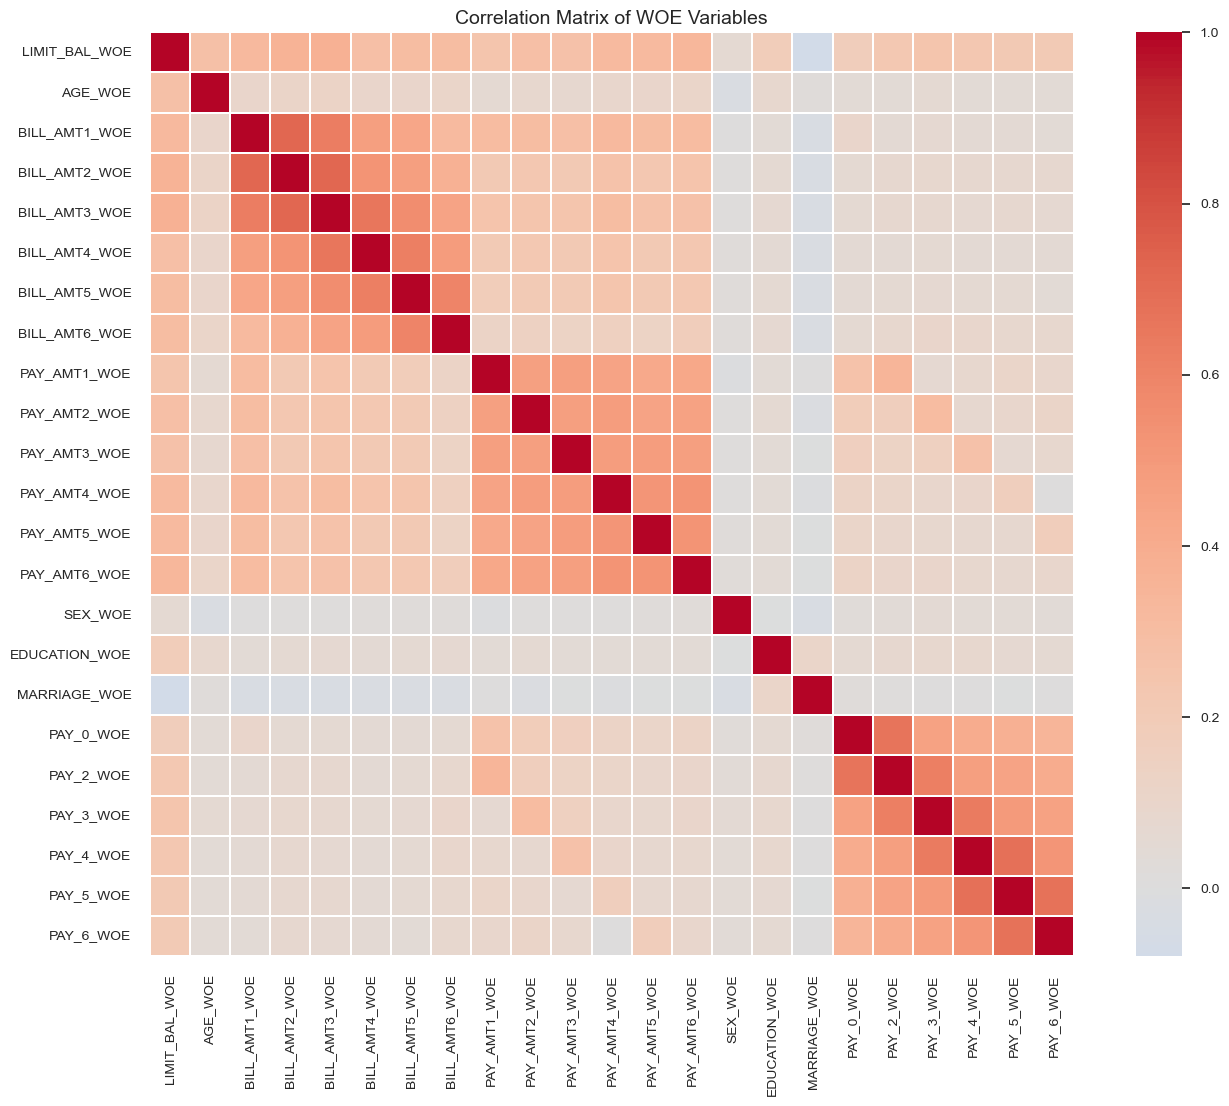

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

sns.heatmap(
    X_train_woe.corr(),
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.3
)

plt.title('Correlation Matrix of WOE Variables', fontsize=14)
plt.show()

The correlation analysis indicates moderate to high correlations among monthly billing (BILL_AMT), repayment (PAY_AMT), and repayment status (PAY_0–PAY_6) variables, reflecting the temporal relationship of customer behaviour across consecutive months. Demographic variables exhibit minimal correlation with other predictors. Correlation analysis alone is insufficient for feature elimination; therefore, Variance Inflation Factor (VIF) analysis is subsequently performed to quantify multicollinearity prior to model development.

In [74]:
#Checking VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif['Variable'] = X_train_woe.columns

vif['VIF'] = [
    variance_inflation_factor(X_train_woe.values, i)
    for i in range(X_train_woe.shape[1])
]

vif = vif.sort_values('VIF', ascending=False)

vif

,Variable,VIF
20,PAY_4_WOE,3.02
21,PAY_5_WOE,3.00
18,PAY_2_WOE,2.95
19,PAY_3_WOE,2.87
3,BILL_AMT2_WOE,2.85
4,BILL_AMT3_WOE,2.85
2,BILL_AMT1_WOE,2.41
22,PAY_6_WOE,2.20
5,BILL_AMT4_WOE,2.16
6,BILL_AMT5_WOE,2.12


Variance Inflation Factor (VIF) analysis indicates low multicollinearity among the WOE-transformed predictors, with all variables exhibiting VIF values below 5. Although moderate correlations were observed among the monthly billing, payment, and repayment status variables, the corresponding VIF values remain within acceptable limits. Therefore, no variables were removed at this stage based solely on multicollinearity.

### Model Developement

In [75]:
import statsmodels.api as sm

# Add intercept
X_train_sm = sm.add_constant(X_train_woe)
X_test_sm = sm.add_constant(X_test_woe)

# Fit logistic regression
logit_model = sm.Logit(y_train, X_train_sm)

result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.431323
         Iterations 6
                               Logit Regression Results                               
Dep. Variable:     default.payment.next.month   No. Observations:                21000
Model:                                  Logit   Df Residuals:                    20976
Method:                                   MLE   Df Model:                           23
Date:                        Sat, 25 Jul 2026   Pseudo R-squ.:                  0.1837
Time:                                20:56:13   Log-Likelihood:                -9057.8
converged:                               True   LL-Null:                       -11097.
Covariance Type:                    nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.2468      0.019   

Using statsmodel as it provides coefficient estimates, p-values, confidence intervals, and statistical significance.

The initial logistic regression model converged successfully and identified several statistically significant predictors of default. Repayment status (PAY_0, PAY_3–PAY_6), payment amounts, credit limit, and demographic variables exhibited significant associations with default probability. Several monthly billing amount variables and PAY_2 were not statistically significant and will be reviewed through iterative backward elimination to obtain a more parsimonious and interpretable model.

In [76]:
### Elimination function
def backward_elimination(X, y, significance_level=0.05):

    X_selected = X.copy()
    removed_variables = []

    while True:

        X_sm = sm.add_constant(X_selected)

        model = sm.Logit(y, X_sm).fit(disp=False)

        p_values = model.pvalues.drop('const')

        max_p = p_values.max()

        if max_p <= significance_level:
            break

        remove_var = p_values.idxmax()

        removed_variables.append((remove_var, max_p))

        print(f"Removing {remove_var} (p-value = {max_p:.4f})")

        X_selected = X_selected.drop(columns=remove_var)

    return model, X_selected, removed_variables

In [77]:
final_model, X_train_final, removed_variables = backward_elimination(
    X_train_woe,
    y_train
)

Removing PAY_2_WOE (p-value = 0.9643)
Removing BILL_AMT5_WOE (p-value = 0.7848)
Removing BILL_AMT6_WOE (p-value = 0.6286)
Removing BILL_AMT2_WOE (p-value = 0.4089)
Removing PAY_AMT5_WOE (p-value = 0.2000)
Removing BILL_AMT4_WOE (p-value = 0.1930)
Removing PAY_AMT4_WOE (p-value = 0.0717)


In [78]:
print(final_model.summary())

                               Logit Regression Results                               
Dep. Variable:     default.payment.next.month   No. Observations:                21000
Model:                                  Logit   Df Residuals:                    20983
Method:                                   MLE   Df Model:                           16
Date:                        Sat, 25 Jul 2026   Pseudo R-squ.:                  0.1834
Time:                                20:56:13   Log-Likelihood:                -9061.6
converged:                               True   LL-Null:                       -11097.
Covariance Type:                    nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.2461      0.019    -65.554      0.000      -1.283      -1.209
LIMIT_BAL_WOE    -0.4714      0.051     -9.201      0.000 

An iterative backward elimination procedure was performed using a 5% significance level to remove statistically insignificant predictors from the initial logistic regression model. The final model retained 16 statistically significant variables, while eliminating predictors that provided limited incremental explanatory power. The model's McFadden's Pseudo R² remained virtually unchanged (0.1837 → 0.1834), indicating that the removed variables contributed minimal additional predictive information.

### Model Evaluation

#### Generating Predicted Probabilities

In [79]:
# Align test data with the variables retained in the final model
X_test_final = X_test_woe[X_train_final.columns]

# Add intercept
X_test_final_sm = sm.add_constant(X_test_final)

# Predicted probability of default
y_pred_prob = final_model.predict(X_test_final_sm)

y_pred_prob.head()

8941    0.12
17618   0.28
27895   0.10
16103   0.61
4422    0.12
dtype: float64

#### Converting Probability into Predicted Class

In [80]:
y_pred = np.where(y_pred_prob >= 0.5, 1, 0)

y_pred

array([0, 0, 0, ..., 0, 0, 0])

#### Confusion Matrix

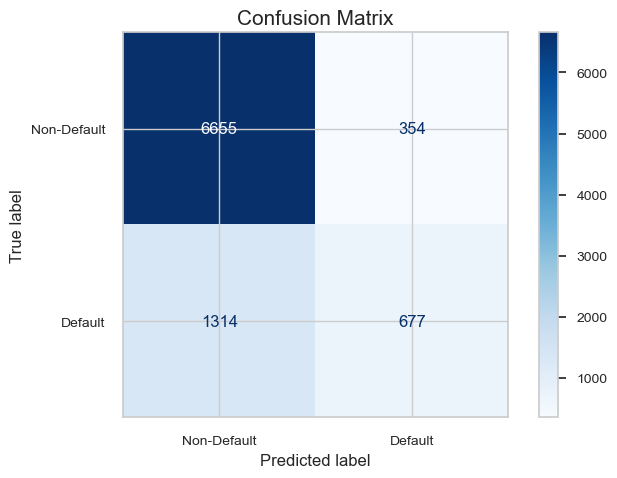

In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Default', 'Default']
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

The model correctly classified 6,655 non-default and 677 default customers. While the model demonstrates strong performance in identifying non-default customers, a proportion of default accounts remain misclassified, which is reflected in the relatively lower recall.

#### Classification Metrics

In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

Accuracy : 0.8147
Precision: 0.6566
Recall   : 0.3400
F1 Score : 0.4480


The model achieved an accuracy of 81.5% with a precision of 65.7%, indicating that nearly two-thirds of customers predicted as defaulters were actual defaulters. The recall of 34.0% suggests that a considerable proportion of default cases were not identified using the default probability threshold of 0.50.

#### ROC-AUC

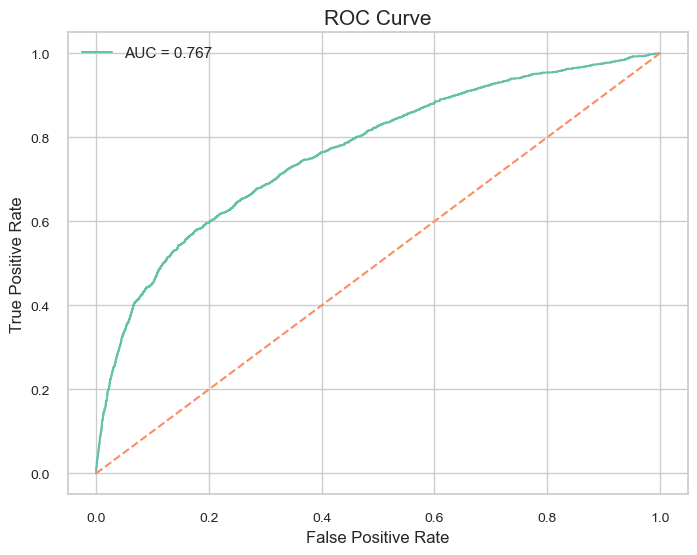

In [83]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.3f}")

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [84]:
auc = roc_auc_score(y_test, y_pred_prob)

print(f"ROC-AUC : {auc:.4f}")

ROC-AUC : 0.7666


The model achieved a ROC-AUC of 0.767, indicating good discriminatory power between default and non-default customers. The ROC curve remains consistently above the random classifier baseline, demonstrating that the model effectively ranks customers according to their probability of default.

The classification metrics reported above are based on a 0.50 probability threshold.

### KS Statistic and Decile Analysis

In [85]:
ks_df = pd.DataFrame({
    'Actual': y_test,
    'Probability': y_pred_prob
})

ks_df = ks_df.sort_values(
    by='Probability',
    ascending=False
).reset_index(drop=True)

In [86]:
ks_df['Decile'] = pd.qcut(
    ks_df.index,
    q=10,
    labels=False
) + 1

In [87]:
ks_table = (
    ks_df
    .groupby('Decile')
    .agg(
        Total=('Actual', 'count'),
        Bad=('Actual', 'sum')
    )
)

ks_table['Good'] = ks_table['Total'] - ks_table['Bad']

In [88]:
ks_table['Bad Rate'] = (
    ks_table['Bad'] /
    ks_table['Total']
)

In [89]:
overall_bad_rate = y_test.mean()

In [90]:
total_good = ks_table['Good'].sum()
total_bad = ks_table['Bad'].sum()

ks_table['Cum Good %'] = (
    ks_table['Good']
    .cumsum()
    / total_good
)

ks_table['Cum Bad %'] = (
    ks_table['Bad']
    .cumsum()
    / total_bad
)

ks_table['KS'] = abs(
    ks_table['Cum Bad %']
    -
    ks_table['Cum Good %']
)


In [91]:
ks_table['Lift'] = (
    ks_table['Bad Rate'] /
    overall_bad_rate
)

In [92]:
ks_table.rename(
    columns={'Cum Bad %':'Cum Bad Capture'},
    inplace=True
)

In [93]:
ks_table.rename(
    columns={'Cum Good %':'Cum Good Capture'},
    inplace=True
)

In [94]:
ks_table = ks_table[
    [
        'Total',
        'Good',
        'Bad',
        'Bad Rate',
        'Lift',
        'Cum Good Capture',
        'Cum Bad Capture',
        'KS'
    ]
]

ks_table.round(3)

,Total,Good,Bad,Bad Rate,Lift,Cum Good Capture,Cum Bad Capture,KS
Decile,,,,,,,,
1,900,296,604,0.67,3.03,0.04,0.30,0.26
2,900,520,380,0.42,1.91,0.12,0.49,0.38
3,900,671,229,0.25,1.15,0.21,0.61,0.40
4,900,722,178,0.20,0.89,0.32,0.70,0.38
5,900,746,154,0.17,0.77,0.42,0.78,0.35
6,900,766,134,0.15,0.67,0.53,0.84,0.31
7,900,783,117,0.13,0.59,0.64,0.90,0.26
8,900,815,85,0.09,0.43,0.76,0.94,0.19
9,900,846,54,0.06,0.27,0.88,0.97,0.09


The decile analysis demonstrates effective risk stratification, with the top 10% highest-risk customers accounting for approximately 30% of all defaults, while the top 30% capture over 60% of defaults. The bad rate and lift decline consistently across successive deciles, confirming the model's strong discriminatory ability and its effectiveness in ranking customers by probability of default.

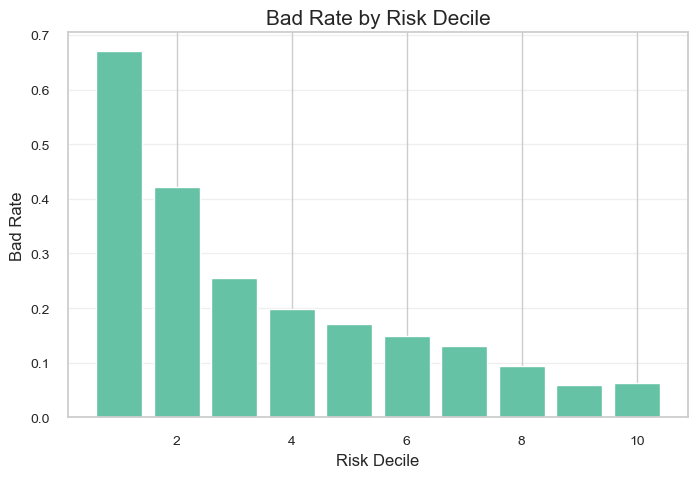

In [95]:
plt.figure(figsize=(8,5))

plt.bar(
    ks_table.index.astype(int),
    ks_table['Bad Rate']
)

plt.xlabel("Risk Decile")
plt.ylabel("Bad Rate")
plt.title("Bad Rate by Risk Decile")

plt.grid(axis='y', alpha=0.3)

plt.show()

The bad rate decreases consistently from the highest-risk to the lowest-risk deciles, indicating that the model effectively ranks customers according to their probability of default. Customers in the top risk decile exhibit substantially higher default rates than those in the lower deciles, demonstrating good discriminatory power.

In [96]:
ks = ks_table['KS'].max()

print(f"KS Statistic : {ks:.4f}")

KS Statistic : 0.3971


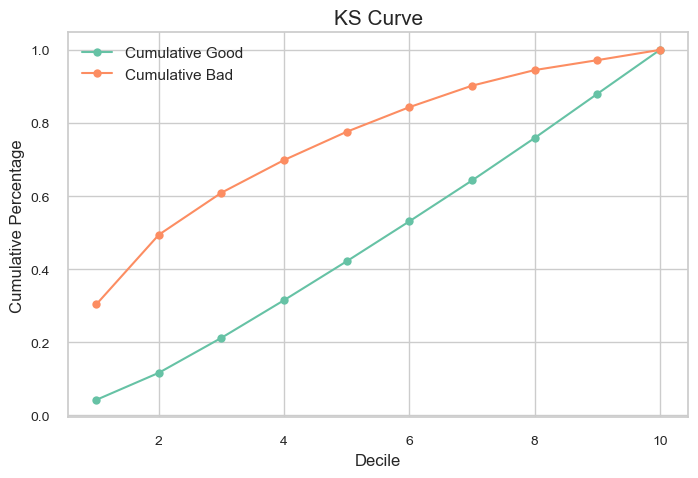

In [97]:
plt.figure(figsize=(8,5))

plt.plot(
    ks_table.index,
    ks_table['Cum Good Capture'],
    marker='o',
    label='Cumulative Good'
)

plt.plot(
    ks_table.index,
    ks_table['Cum Bad Capture'],
    marker='o',
    label='Cumulative Bad'
)

plt.title("KS Curve")
plt.xlabel("Decile")
plt.ylabel("Cumulative Percentage")

plt.legend()

plt.show()

The model achieved a KS Statistic of 39.7%, indicating fair to good discriminatory power between default and non-default customers. The maximum separation between cumulative good and bad customer distributions occurred in the third decile, demonstrating the model's ability to effectively rank customers according to their default risk.

#### Determine the Optimal Threshold

- J=Sensitivity−False Positive Rate
- Rather than using the default 0.50, we'll choose the threshold that maximises Youden's J statistic:

In [98]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

youden = tpr - fpr

best_idx = np.argmax(youden)

best_threshold = thresholds[best_idx]

print(f"Optimal Threshold : {best_threshold:.4f}")

Optimal Threshold : 0.2240


In [99]:
y_pred_opt = (y_pred_prob >= best_threshold).astype(int)

In [100]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(f"Accuracy : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_opt):.4f}")

Accuracy : 0.7700
Precision: 0.4834
Recall   : 0.5781
F1 Score : 0.5265


In [101]:
comparison_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Threshold = 0.50': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    f'Threshold = {best_threshold:.3f}': [
        accuracy_score(y_test, y_pred_opt),
        precision_score(y_test, y_pred_opt),
        recall_score(y_test, y_pred_opt),
        f1_score(y_test, y_pred_opt)
    ]
})

comparison_table.iloc[:, 1:] = comparison_table.iloc[:, 1:].round(4)

comparison_table

,Metric,Threshold = 0.50,Threshold = 0.224
0,Accuracy,0.81,0.77
1,Precision,0.66,0.48
2,Recall,0.34,0.58
3,F1 Score,0.45,0.53


Optimising the probability threshold from 0.50 to 0.224 substantially improved the model's ability to identify defaulters, with recall increasing from 34.0% to 57.8% and the F1-score improving from 44.8% to 52.7%. Although this resulted in a modest reduction in accuracy and precision, the revised threshold provides a better balance between identifying default customers and minimizing missed defaults, making it more suitable for credit risk applications.

### Score Scaling

The logistic regression model produces predictions as log-odds, which are not intuitive for business users. Score scaling converts these log-odds into a credit score, making customer risk easier to interpret and compare.

##### Key Parameters

- Base Score: The reference credit score assigned to a predefined level of risk. In this project, a score of 600 corresponds to odds of 50:1 (50 non-defaulting customers for every 1 defaulting customer).
- Base Odds: The reference odds used for score calibration. Higher odds indicate lower default risk.
- Points to Double the Odds (PDO): The number of points required for the odds of non-default to double. A PDO of 20 means that increasing a customer's score by 20 points doubles their odds of being a good customer.

Using these parameters, the model calculates a scaling factor and offset, which transform predicted log-odds into an interpretable credit score while preserving the relative ranking of customer risk.

In [102]:
PDO = 20
Base_Score = 600
Base_Odds = 50

Factor = PDO / np.log(2)

Offset = Base_Score - Factor * np.log(Base_Odds)

print(f"Factor : {Factor:.4f}")
print(f"Offset : {Offset:.4f}")

Factor : 28.8539
Offset : 487.1229


In [103]:
log_odds = np.log(
    y_pred_prob /
    (1 - y_pred_prob)
)
log_odds

8941    -2.02
17618   -0.96
27895   -2.20
16103    0.46
4422    -2.03
         ... 
27933   -2.27
26623   -1.70
21750   -1.81
14888   -0.79
20705   -1.93
Length: 9000, dtype: float64

In [104]:
credit_score = Offset - Factor * log_odds

In [105]:
score_df = pd.DataFrame({
    'Actual': y_test,
    'PD': y_pred_prob,
    'Score': credit_score
})

score_df.head()

,Actual,PD,Score
8941,0,0.12,545.49
17618,1,0.28,514.76
27895,0,0.10,550.47
16103,0,0.61,473.99
4422,0,0.12,545.69


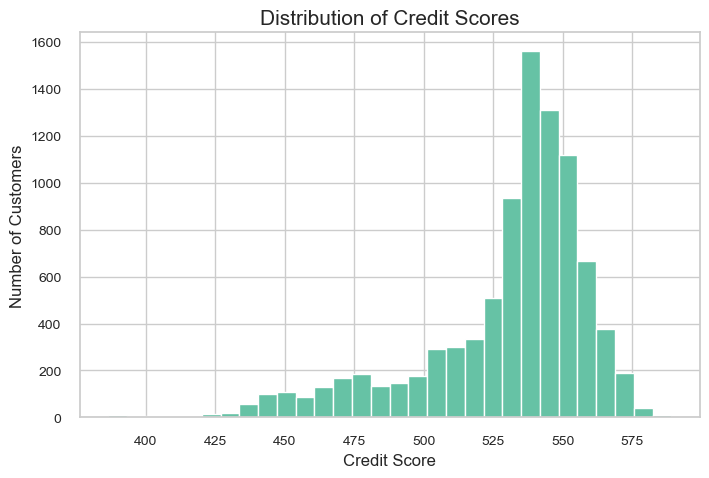

In [106]:
plt.figure(figsize=(8,5))

plt.hist(score_df['Score'], bins=30)

plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.title("Distribution of Credit Scores")

plt.show()

The score distribution exhibits a near bell-shaped pattern, with the majority of customers concentrated between 530 and 550. Lower credit scores correspond to customers with higher predicted probabilities of default, while higher scores indicate lower-risk customers.

### Scorecard Generation

#### Mathematical Basis of Score Scaling

Before implementing score scaling, it is useful to understand how the logistic regression model is converted into a traditional credit scorecard.

The fitted logistic regression model estimates the **log-odds of default** as:

$$
\log\left(\frac{P(\text{Default})}{1-P(\text{Default})}\right)
=
\beta_0+\sum_{i=1}^{N}\beta_i \times WOE_i
$$

A traditional scorecard converts these log-odds into an interpretable credit score using the scaling equation:

$$
\text{Score} = \text{Offset} - \text{Factor} \times \text{Log Odds}
$$

Substituting the logistic regression equation into the score scaling formula:

$$
\text{Score}
=
\text{Offset}
-
\text{Factor}
\left(
\beta_0+\sum_{i=1}^{N}\beta_i \times WOE_i
\right)
$$

To assign points to each predictor independently, the model intercept is distributed equally across all variables in the final model.

Therefore, the contribution of each variable to the final score is calculated as:

$$
\text{Points}_i
=
-
\left(
\beta_i \times WOE_i
+
\frac{\beta_0}{N}
\right)
\times
\text{Factor}
$$

where:

- $N$ = Number of variables in the final scorecard
- $\beta_0$ = Logistic regression intercept
- $\beta_i$ = Logistic regression coefficient of variable *i*
- $WOE_i$ = Weight of Evidence corresponding to the customer's bin
- **Factor** = Scaling constant derived from the selected Points to Double the Odds (PDO)

This formulation converts the logistic regression model into a transparent, additive scorecard where each variable contributes a fixed number of points to the customer's final credit score.

In [107]:
coefficients = final_model.params

coefficients

const           -1.25
LIMIT_BAL_WOE   -0.47
AGE_WOE         -0.28
BILL_AMT1_WOE    0.77
BILL_AMT3_WOE    0.74
PAY_AMT1_WOE    -0.26
PAY_AMT2_WOE    -0.29
PAY_AMT3_WOE    -0.27
PAY_AMT6_WOE    -0.24
SEX_WOE         -0.60
EDUCATION_WOE   -0.32
MARRIAGE_WOE    -1.04
PAY_0_WOE       -0.76
PAY_3_WOE       -0.16
PAY_4_WOE       -0.13
PAY_5_WOE       -0.20
PAY_6_WOE       -0.21
dtype: float64

In [108]:
factor = PDO / np.log(2)

offset = Base_Score - factor * np.log(Base_Odds)

base_points = offset - factor * coefficients['const']

print(base_points)

523.0784975182067


In [109]:
def generate_scorecard(variable, woe_table, coefficients, factor):

    coef = coefficients[variable + "_WOE"]

    # Continuous variables
    if variable + "_BIN" in woe_table.columns:
        bins = woe_table[variable + "_BIN"].astype(str)

    # Categorical variables
    else:
        bins = woe_table[variable].astype(str)

    scorecard = pd.DataFrame({
        "Variable": variable,
        "Bin": bins,
        "Points": (-coef * woe_table["WOE"] * factor).round().astype(int)
    })

    return scorecard

In [110]:
scorecard = []

for col in continuous_cols:
    if col + "_WOE" in coefficients.index:
        scorecard.append(
            generate_scorecard(
                col,
                continuous_woe_tables[col],
                coefficients,
                factor
            )
        )

for col in categorical_cols:
    if col + "_WOE" in coefficients.index:
        scorecard.append(
            generate_scorecard(
                col,
                categorical_woe_tables[col],
                coefficients,
                factor
            )
        )

In [111]:
scorecard = pd.concat(scorecard)

scorecard.reset_index(drop=True, inplace=True)

In [112]:
scorecard.head(20)

,Variable,Bin,Points
0,LIMIT_BAL,"(9999.999, 30000.0]",-10
1,LIMIT_BAL,"(30000.0, 50000.0]",-3
2,LIMIT_BAL,"(50000.0, 70000.0]",-5
3,LIMIT_BAL,"(70000.0, 100000.0]",-1
4,LIMIT_BAL,"(100000.0, 140000.0]",-1
5,LIMIT_BAL,"(140000.0, 180000.0]",4
6,LIMIT_BAL,"(180000.0, 210000.0]",4
7,LIMIT_BAL,"(210000.0, 270000.0]",5
8,LIMIT_BAL,"(270000.0, 360000.0]",7
9,LIMIT_BAL,"(360000.0, 1000000.0]",11


The generated scorecard converts the WOE-transformed logistic regression model into a practical points-based scoring system. Each variable bin is assigned a point contribution based on its relative impact on default risk, with lower-risk bins receiving higher points and higher-risk bins receiving lower or negative points. A customer's final credit score is obtained by summing the points across all applicable variable bins.

### Scorecard Validation with a Sample Customer

In [113]:
customer = X_test.iloc[[0]]

In [114]:
worked_example = pd.DataFrame({
    "Variable": customer.columns,
    "Customer Value": customer.iloc[0].values
})

In [115]:
worked_example

,Variable,Customer Value
0,LIMIT_BAL,230000.00
1,SEX,1.00
2,EDUCATION,2.00
3,MARRIAGE,2.00
4,AGE,30.00
5,PAY_0,0.00
6,PAY_2,0.00
7,PAY_3,0.00
8,PAY_4,0.00
9,PAY_5,0.00


In [116]:
def get_bin_points(variable, value, scorecard):

    rows = scorecard[scorecard["Variable"] == variable]

    for _, row in rows.iterrows():

        bin_str = row["Bin"]

        # Continuous variable (interval)
        if "(" in bin_str:

            interval = pd.Interval(
                left=float(bin_str.split(",")[0].replace("(", "")),
                right=float(bin_str.split(",")[1].replace("]", "")),
                closed="right"
            )

            if value in interval:
                return bin_str, row["Points"]

        # Categorical variable
        else:
            if float(value) == float(bin_str):
                return bin_str, row["Points"]

    return None, None

In [117]:
worked_example["Bin"] = None
worked_example["Points"] = None

for i in worked_example.index:

    variable = worked_example.loc[i, "Variable"]
    value = worked_example.loc[i, "Customer Value"]

    bin_, points = get_bin_points(variable, value, scorecard)

    worked_example.loc[i, "Bin"] = bin_
    worked_example.loc[i, "Points"] = points

In [118]:
final_variables = scorecard["Variable"].unique()

worked_example = worked_example[
    worked_example["Variable"].isin(final_variables)
].reset_index(drop=True)

worked_example

,Variable,Customer Value,Bin,Points
0,LIMIT_BAL,230000.00,"(210000.0, 270000.0]",5
1,SEX,1.00,1,-2
2,EDUCATION,2.00,2,-1
3,MARRIAGE,2.00,2,2
4,AGE,30.00,"(29.0, 31.0]",1
5,PAY_0,0.00,0,15
6,PAY_3,0.00,0,1
7,PAY_4,0.00,0,1
8,PAY_5,0.00,0,1
9,PAY_6,0.00,0,1


In [119]:
print(f"Total Variable Points : {worked_example['Points'].sum()}")

print(f"Final Credit Score : {base_points + worked_example['Points'].sum():.0f}")

Total Variable Points : 20
Final Credit Score : 543


For the selected customer, the final credit score is 543, obtained by adding the base points to the total variable points derived from the scorecard.

## Business Conclusion
- Developed a traditional Probability of Default (PD) scorecard using Weight of Evidence (WOE) transformation and logistic regression.
- Performed feature selection through Information Value (IV), multicollinearity analysis, and backward elimination to obtain a statistically significant and interpretable model.
- Achieved a ROC-AUC of 0.767 and a KS Statistic of 39.7%, demonstrating good discriminatory power in distinguishing defaulting and non-defaulting customers.
- Optimised the classification threshold from 0.50 to 0.224, improving recall and F1-score while maintaining a balanced trade-off between precision and sensitivity.
- Converted the final model into a points-based credit scorecard, enabling transparent, interpretable, and business-friendly customer risk assessment.
- Demonstrated the practical application of the scorecard by calculating the credit score for an individual customer based on the final scoring rules.

## Future Work

Potential improvements to this study include:

- Validate the scorecard using an Out-of-Time (OOT) dataset.
- Monitor Population Stability Index (PSI) to detect model drift after deployment.
- Compare the scorecard with advanced machine learning models such as XGBoost or LightGBM.
- Incorporate macroeconomic variables to improve model robustness across economic cycles.
- Extend the framework to include LGD and EAD modelling for a complete credit risk solution.
##### This is an ongoing project, and I hope to add further to it. 